# Part A: GAN Improvements and Experiments

This notebook starts from the trained PyTorch conditional DCGAN baseline, tests one change at a time, and retrains the best eligible single improvement as a final model evaluated against the same recorded baseline.

## 1. Imports and Setup

In [1]:
import json
import os
import re
from pathlib import Path

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from torchvision.transforms import transforms
import torch.nn.functional as F
from torchvision.transforms import functional as F_t
from torchvision.datasets import CIFAR10
import datasets 
import matplotlib.pyplot as plt

# Match the baseline's random seed and use the GPU when one is available.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)
cpu_cores = min(12, os.cpu_count()-2 or 1)
# Reuse the available CPU workers for cached Hugging Face preprocessing too.
map_workers = min(6, cpu_cores)
print(f'running on {device}')


C:\Users\Admin\Desktop\st1504-ca2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


running on cuda


In [2]:
import seaborn as sns

# Shared design system for the Part A notebooks: one categorical color per CIFAR-10 class.
PALETTE = [
    "#A1533F",  # 0 airplane   - terracotta
    "#C08A3E",  # 1 automobile - ochre
    "#3D8049",  # 2 bird       - sage
    "#24558F",  # 3 cat        - slate blue
    "#8A3466",  # 4 deer       - plum
    "#4552A8",  # 5 dog        - indigo
    "#8C3F32",  # 6 frog       - brick red
    "#B79A2E",  # 7 horse      - mustard
    "#B5615B",  # 8 ship       - rose
    "#6B7A1A",  # 9 truck      - olive
]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

In [3]:
class generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.proj = nn.Linear(noise_dim + 10, 128*4*4)
        self.bn_proj = nn.BatchNorm1d(128*4*4)
        self.convT1 = nn.ConvTranspose2d(128, 64, 4, 2, 1) # 4x4 -> 8x8
        self.bn1 = nn.BatchNorm2d(64)

        self.convT2 = nn.ConvTranspose2d(64, 32, 4, 2, 1) # 8x8 -> 16x16
        self.bn2 = nn.BatchNorm2d(32)

        self.convT3 = nn.ConvTranspose2d(32, 3, 4, 2, 1) # 16x16 -> 32x32

        #activations
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()



    def forward(self, noise, label):
        x = torch.concat((noise, label), dim=-1)
        x = self.relu(self.bn_proj(self.proj(x)))
        x = x.reshape(-1, 128, 4, 4)
        
        x = self.relu(self.bn1(self.convT1(x)))
        x = self.relu(self.bn2(self.convT2(x)))
        x = self.tanh(self.convT3(x))
        return x

class discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 3, 2, 1) # 32x32 -> 16x16

        self.conv2 = nn.Conv2d(32, 64, 3, 2, 1) # 16x16 -> 8x8
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, 2, 1) # 8x8 -> 4x4
        self.bn3 = nn.BatchNorm2d(128)

        self.fc_out = nn.Linear(128*4*4, 1) 
        # activations
        
        self.leakyrelu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()

        # reg
        self.dropout2d = nn.Dropout2d(0.3)
        
    def forward(self, x, label):
        batch_size = x.size(0)
        label = label.reshape(batch_size, 10, 1, 1).expand(batch_size, 10, 32, 32)
        x = torch.concat((x, label), dim=-3)
        x = self.leakyrelu(self.conv1(x))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn2(self.conv2(x)))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn3(self.conv3(x)))
        x = self.dropout2d(x)
        x = x.flatten(start_dim=1)
        x = self.sigmoid(self.fc_out(x))
        return x

noise_dim = 128
bs = 128
validation_n_samples=5
classes  = ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

def set_requires_grad(model, yesno):
    for param in model.parameters():
        param.requires_grad_(yesno)

def print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss):
    print(f'D(x) = {D_x:.4f}')
    print(f'D(G(z)) = {D_Gz:.4f}')
    print(f'D Loss (real): {real_d_loss:.3f} | D Loss (fake): {fake_d_loss:.3f}')
    print(f'Generator Loss: {g_loss:.3f}')

val_noise = torch.randn((bs, noise_dim)).to(device)

def track_metrics(train_val, D_x, D_Gz, real_d_loss, fake_d_loss, g_loss):
    D_x_track[train_val].append(D_x.item())
    D_Gz_track[train_val].append(D_Gz.item())
    real_d_loss_track[train_val].append(real_d_loss.item())
    fake_d_loss_track[train_val].append(fake_d_loss.item())
    g_loss_track[train_val].append(g_loss.item())


def generate_class_images(G, n, e):
    G.eval()
    fixed_noise_progression_grid[e + 1] = []

    with torch.no_grad():
        fig, ax = plt.subplots(n, 10, figsize=(12, 5))
        for col, a in enumerate(ax[0]):
            a.set_title(f"{classes[col]}", pad=10)

        for idx in range(10):
            one_hot_label = [0] * 10
            one_hot_label[idx] = 1
            one_hot_label = torch.Tensor(one_hot_label).expand(n, -1).to(device)
            noise = val_noise[0:n].to(device)
            per_class_generated_imgs = G(noise, one_hot_label)

            fixed_noise_progression_grid[e + 1].append(
                per_class_generated_imgs[0].detach().cpu().numpy()
            )

            for img in range(per_class_generated_imgs.size(0)):
                ax[img][idx].imshow(F_t.to_pil_image(
                    (127.5 * (per_class_generated_imgs[img] + 1)).to(torch.uint8)
                ))
                ax[img][idx].axis("off")

        plt.tight_layout()
        plt.show()



## 2. Load Recorded Experiment Results

The saved ablation file contains the baseline run, every experiment, and the final model from that suite. Those recorded baseline values remain the fixed reference throughout this notebook; a later standalone rerun of `gan_baseline.ipynb` may differ slightly because GAN training is stochastic and is not substituted into this historical ablation.

In [4]:
def one_hot_encode(batch):
    labels = []
    for n in batch:
        r = [0]*10
        r[n.item()] = 1
        labels.append(r)
    return {'label': labels}
def complete_cache_shard_sets(cache_dir):
    """Yield complete cache-file families for any shard count."""
    for first_file in sorted(cache_dir.glob("cache-*.arrow")):
        match = re.fullmatch(
            r"(?P<prefix>cache-.+)_00000_of_(?P<count>\d{5})\.arrow",
            first_file.name,
        )
        if match:
            shard_count = int(match.group("count"))
            if shard_count < 1:
                continue
            prefix = match.group("prefix")
            shards = [
                cache_dir / f"{prefix}_{index:05d}_of_{shard_count:05d}.arrow"
                for index in range(shard_count)
            ]
            if all(shard.is_file() for shard in shards):
                yield first_file, shards
        elif "_of_" not in first_file.stem:
            yield first_file, [first_file]

def cached_processed_split(cache_dir, total_rows):
    candidates = []
    for first_file, shards in complete_cache_shard_sets(cache_dir):
        try:
            first_part = datasets.Dataset.from_file(str(first_file))
            if not {'img', 'label'}.issubset(first_part.column_names):
                continue
            label_feature = first_part.features.get('label')
            image_feature = first_part.features.get('img')
            if getattr(getattr(label_feature, 'feature', None), 'dtype', None) != 'int64':
                continue
            image_leaf = getattr(getattr(getattr(image_feature, 'feature', None), 'feature', None), 'feature', None)
            if getattr(image_leaf, 'dtype', None) != 'float32':
                continue

            first_sample = first_part.with_format('torch')[0]
            if tuple(first_sample['img'].shape) != (3, 32, 32):
                continue
            if tuple(first_sample['label'].shape) != (10,):
                continue

            combined = datasets.concatenate_datasets([
                datasets.Dataset.from_file(str(shard)) for shard in shards
            ])
            if len(combined) != total_rows:
                continue

            check_data = combined.with_format('torch')
            check_indices = [0, total_rows // 2, total_rows - 1]
            compatible = True
            for index in check_indices:
                sample = check_data[index]
                image = sample['img']
                label = sample['label']
                compatible &= image.dtype == torch.float32
                compatible &= bool(torch.isfinite(image).all())
                compatible &= float(image.min()) >= -1.0 and float(image.max()) <= 1.0
                compatible &= label.dtype == torch.int64 and tuple(label.shape) == (10,)
                compatible &= bool(((label == 0) | (label == 1)).all())
                compatible &= int(label.sum()) == 1
            if compatible:
                newest_mtime = max(shard.stat().st_mtime for shard in shards)
                candidates.append((newest_mtime, combined))
        except (OSError, ValueError, TypeError, KeyError):
            continue

    return max(candidates, key=lambda item: item[0])[1] if candidates else None

cifar_cache_files = sorted(
    Path(datasets.config.HF_DATASETS_CACHE).glob(
        'uoft-cs___cifar10/plain_text/*/*/cifar10-train.arrow'
    )
)
cached_train = cached_test = None
if cifar_cache_files:
    cifar_cache_dir = cifar_cache_files[-1].parent
    cached_train = cached_processed_split(cifar_cache_dir, 50000)
    cached_test = cached_processed_split(cifar_cache_dir, 10000)

if cached_train is not None and cached_test is not None:
    train_data = cached_train.with_format('torch')
    test_data = cached_test.with_format('torch')
    print(f'using cached normalized and one-hot CIFAR-10 shards from {cifar_cache_dir}')
else:
    if cifar_cache_files:
        image_data = datasets.DatasetDict({
            'train': datasets.Dataset.from_file(str(cifar_cache_dir / 'cifar10-train.arrow')),
            'test': datasets.Dataset.from_file(str(cifar_cache_dir / 'cifar10-test.arrow')),
        }).with_format('torch')
    else:
        image_data = datasets.load_dataset('uoft-cs/cifar10').with_format('torch')
    train_data = image_data['train'].map(lambda x: {'img': x/127.5 - 1}, input_columns=['img'], batched=True, batch_size=500, num_proc=map_workers)
    test_data = image_data['test'].map(lambda x: {'img': x/127.5 - 1}, input_columns=['img'], batched=True, batch_size=500, num_proc=map_workers)
    train_data = train_data.map(one_hot_encode, input_columns=['label'], batched=True, batch_size=500, num_proc=map_workers)
    test_data = test_data.map(one_hot_encode, input_columns=['label'], batched=True, batch_size=500, num_proc=map_workers)

sample_batch = torch.tensor(test_data.select(range(64)).with_format(None)['img'])
print(f'range: {sample_batch.min()} to {sample_batch.max()}')

shuffled = train_data.shuffle(seed=42, keep_in_memory=True)
val_data = shuffled.select(range(5000))
train_data = shuffled.select(range(5000, len(shuffled)))

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=True)


using cached normalized and one-hot CIFAR-10 shards from C:\Users\Admin\.cache\huggingface\datasets\uoft-cs___cifar10\plain_text\0.0.0\0b2714987fa478483af9968de7c934580d0bb9a2
range: -1.0 to 1.0


In [5]:
# Baseline result loading is handled in the next cell.



# BASELINE_RESULTS_PATH = Path("gan_baseline_results.json")
# if not BASELINE_RESULTS_PATH.exists():
#     raise FileNotFoundError(
#         "gan_baseline_results.json was not found. Run gan_baseline.ipynb "
#         "through its result-saving cell before running this notebook."
#     )

# with BASELINE_RESULTS_PATH.open(encoding="utf-8") as file:
#     baseline_results = json.load(file)

# baseline_eye_scores = baseline_results["eye_test_scores"]


# baseline_class_quality = {
#     class_name: float(np.mean(baseline_eye_scores[class_name]))
#     for class_name in classes
# }
# baseline_quality_score = float(np.mean(list(baseline_class_quality.values())))
# baseline_loss_balance = abs(
#     baseline_results["final_val_g_loss"] - baseline_results["final_val_d_loss"]
# )

# baseline_summary = pd.Series(
#     {
#         "quality_score": baseline_quality_score,
#         "final_val_g_loss": baseline_results["final_val_g_loss"],
#         "final_val_d_loss": baseline_results["final_val_d_loss"],
#         "g_d_loss_gap": baseline_loss_balance,
#         "fid_score": baseline_results["fid_score"],
#     },
#     name="baseline",
# ).to_frame("value")
# baseline_summary

In [6]:
EXPERIMENT_RESULTS_PATH = Path('../../results/part_a/gan_experiment_results.json')
if not EXPERIMENT_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "gan_experiment_results.json was not found. This file holds the manual "
        "visual-review score and every experiment's recorded metrics, so this "
        "notebook doesn't need to retrain all 10 experiments just to rebuild the "
        "ablation table."
    )

with EXPERIMENT_RESULTS_PATH.open(encoding="utf-8") as file:
    experiment_results = json.load(file)

# Keep the baseline from the same saved experiment suite so every comparison uses
# metrics produced under the same run conditions.
baseline_summary = pd.Series(
    experiment_results["baseline"], name="baseline"
).reindex([
    "quality_score",
    "final_val_g_loss",
    "final_val_real_d_loss",
    "final_val_fake_d_loss",
    "fid_score",
]).to_frame("value")
baseline_summary

,value
quality_score,0.220000
final_val_g_loss,0.908666
final_val_real_d_loss,0.546201
final_val_fake_d_loss,0.552436
fid_score,121.398079


## 3. Comparison Metrics

The comparison criteria are defined before interpreting the experiments so that every change is judged against the same baseline rather than selected retrospectively from whichever result looks most favorable.

### 3.1 FID and the image-quality reviews

![FID evaluation pipeline](../../images/gan-fid-pipeline-academic.png)

FID is the primary metric. The RGB baseline, RGB experiments, and final model use the same TorchMetrics Inception extractor and a 1,000-image budget, although Section 3.4 documents differences in their sampled real and generated sets. Lower is better within that shared RGB representation. Grayscale is evaluated against grayscale-transformed real images, so its FID is a separate within-representation diagnostic rather than a value that can be ranked directly against the RGB FIDs.

Three quality measurements appear in this notebook and they are not interchangeable. FID is reported for all twelve model labels and compares feature distributions, so it says nothing about whether an image carries the label it was asked for; the grayscale value remains separate from the cross-RGB ranking. The manual quality score maps each review label to a number (`clear = 1`, `marginal = 0.5`, `not recognizable = 0`) and averages the values per class and overall; scoring 10 images per class by hand across all ten experiments was not practical, so it covers the baseline and the final model only, which is why the experiment rows carry `NaN` in the `quality_score` column. The blind grid review, set out in Section 3.5, covers all twelve models over the 5 images per class held in each fixed-noise grid, and is the only recognisability measure that spans the whole suite.

FID drives the selection in Section 14.1. The manual score cross-checks the two models it covers. The grid review is used wherever a comparison needs every run, and Section 3.5 tests whether the two full-coverage metrics agree with each other. The chart in Section 15 plots the grid review for all twelve models with the two manual scores marked on it.

In [7]:
# Map clear, marginal, and not-recognizable review labels to a 0-1 quality score.
def score_from_labels(labels):
    # Marginal counts as half-credit rather than being dropped, since it's a real (if weaker) signal of quality, not noise.
    weights = {"c": 1.0, "m": 0.5, "n": 0.0}
    return sum(weights[label] for label in labels) / len(labels)


### 3.2 Discriminator/Generator Loss Balance (secondary / diagnostic metric)

Generator, real-discriminator, and fake-discriminator validation losses are reported separately because no single GAN loss measures image quality; their curves are used only to diagnose instability, collapse, or one network overpowering the other. For the RGB runs, FID uses a common 1,000-image TorchMetrics setup and provides the primary quantitative comparison with the baseline; the grayscale FID is interpreted only within its transformed representation.

One caveat on how these losses are recorded. The training loop calls `track_metrics` once per epoch, after the inner batch loop has already finished, so each stored value comes from that epoch's last minibatch and not from an average over the epoch. The `final_val_*` columns in the ablation table inherit the same property. They are coarse snapshots of the adversarial dynamics, and small differences between them carry little weight. `gan_baseline.ipynb` Section 7.2 makes the same point about its loss curves.

### 3.3 Decision Rule

A setting is treated as an improvement when its FID is lower than the recorded ablation baseline's, provided its loss curves do not show obvious collapse. Grayscale is kept out of the final RGB model and assessed on its own, since it changes both the output representation and the real reference used by FID. The eligible RGB setting with the lowest recorded FID is retrained as the final model, and its manual quality score and FID are compared with that same baseline. Section 3.4 covers how large a FID gap has to be before it means anything, and Section 3.5 tests whether FID is the right quantity to be ranking on at all.

### 3.4 Limitations of the FID protocol

Three properties of how FID is computed here limit how much the small gaps between experiments can be trusted.

The real reference set is not fixed. Each experiment's FID cell collects its 1,000 real images by iterating `val_loader`, which is constructed with `shuffle=True`, so every experiment is scored against a different random draw of real data. The generated set moves as well, because the noise for the fake images comes from whatever the global RNG state happens to be at that point in the notebook and not from a fixed seed.

Grayscale is a separate special case: its FID is computed against grayscale-transformed real images, whereas the RGB models are evaluated against colour real images. Its FID is therefore a within-representation score and is not directly rankable against the RGB FIDs.

The sample size is small. FID is computed from 1,000 images. The estimator is biased upward at small sample sizes and the bias falls as the sample grows, which is why 10,000 to 50,000 images is the usual practice. At 1,000 the absolute values are inflated and carry noticeable run-to-run variance.

The experiments are not seed-controlled against each other. Section 1 seeds once, then each experiment trains in sequence, so every run begins from a different generator initialization and sees a different data order.

The two eligible RGB improvements finished at `117.603` for augmentation and `119.926` for label smoothing, only `2.323` points apart, against the saved baseline's `121.398`. The direct repeat is less reassuring: the same augmentation setup reached `123.503` when retrained as the final model, a `5.900`-point swing from its ablation result and `2.105` points worse than the baseline. The leading order should therefore be treated as tentative rather than as a reliable ranking.


In [8]:
# Start the live rerun table from the saved baseline only.
# Each experiment section appends or replaces its own freshly computed row.
results = pd.DataFrame(experiment_results).T.loc[["baseline"]].copy()
results

,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079


In [9]:
def add_row_to_df(df, row, experiment_name):
    replacement = pd.DataFrame({experiment_name:row}).T
    return pd.concat([df.drop(index=experiment_name, errors="ignore"), replacement], ignore_index=False)
# Experiment result cells below use this helper when rebuilding the table.


### 3.5 Do the two metrics agree?

Sections 3.1 to 3.4 set FID as the primary metric and treat recognisability as a cross-check, but neither establishes that the two rank models the same way. Section 15 reports that test after the live results table contains all twelve model labels.

The blind-review labels and fixed-noise grids are saved evaluation artifacts. Each grid contains five images per class across ten classes, giving 50 reviewed images per model, but the images were not regenerated and the grids were not rescored during this rerun. The fresh FIDs are therefore paired with historical review scores, making the correlations descriptive cross-run comparisons rather than same-run validation. The only fresh subjective review in this notebook is the user's 100-image final-model review in Section 14.3.

Section 14.4 reuses the same saved grids for diversity. A negative rank correlation would be expected if lower FID tracked higher recognisability; a weak or reversed relationship would show that the two metrics order these artifacts differently.


In [22]:
# Define the rank-correlation calculation here; Section 15 runs it after all fresh rows exist.
from scipy.stats import spearmanr

with open("../../results/part_a/gan_grid_review.json", encoding="utf-8") as file:
    grid_review = json.load(file)

collapsed = ["experiment_1_ttur", "experiment_3_spectralnorm"]

def build_metric_agreement(result_frame):
    metric_check = result_frame[["fid_score"]].copy()
    metric_check["grid_review_score"] = pd.Series(grid_review["overall"])

    subsets = {
        "all models": metric_check,
        "excluding collapsed runs": metric_check.drop(collapsed),
        "excluding collapsed runs and grayscale": metric_check.drop(
            collapsed + ["experiment_4_greyscale"]
        ),
    }

    rows = {}
    for name, frame in subsets.items():
        rho, p_value = spearmanr(frame["fid_score"], frame["grid_review_score"])
        rows[name] = {
            "n": len(frame),
            "spearman_rho": round(rho, 3),
            "p_value": round(p_value, 3),
        }

    return pd.DataFrame(rows).T


Lower FID is better and a higher review score is better, so agreement between them would appear as a negative correlation. The correlations reported with the completed ablation table in Section 15 combine the fresh FIDs with the recorded blind reviews of the saved fixed-noise grids; they are a cross-run diagnostic, not a review of the newly generated images.

Across all twelve labels, a completeness-only sensitivity calculation gives Spearman's rho `-0.133` with `p = 0.680`; because it ranks grayscale beside RGB, it is not treated as a like-for-like result. Removing TTUR and spectral normalization leaves another mixed-representation value of `+0.439` (`p = 0.204`). The comparable analysis also removes grayscale and gives `+0.227` across the nine non-collapsed RGB models (`p = 0.557`). None is significant, and the RGB point estimate goes in the opposite direction from the expected relationship.

Grayscale is a special case rather than a directly comparable FID gain. Its within-grayscale FID is `109.258` and its recorded grid-review score is `0.18`; the RGB baseline values of `121.398` and `0.23` provide context, but the `12.140` FID difference crosses output representations and should not be interpreted as an RGB-model improvement.

Nine RGB points cannot rule out a weak relationship, and mixing fresh FIDs with historical grids prevents a same-run validation. The supported conclusion is narrower: this notebook provides no evidence that its RGB FID ordering tracks class recognisability closely enough to use without a class-fidelity cross-check.


In [23]:
# Attach a standard error to each review score, then compare every model with the baseline.
n_images = grid_review["protocol"]["images_per_model"]

review_uncertainty = pd.Series(
    grid_review["overall"], name="grid_review_score"
).to_frame()
review_uncertainty["std_error"] = np.sqrt(
    review_uncertainty["grid_review_score"] * (1 - review_uncertainty["grid_review_score"]) / n_images
)

baseline_score = review_uncertainty.loc["baseline", "grid_review_score"]
baseline_error = review_uncertainty.loc["baseline", "std_error"]
review_uncertainty["gap_vs_baseline"] = review_uncertainty["grid_review_score"] - baseline_score
review_uncertainty["gap_in_std_errors"] = review_uncertainty["gap_vs_baseline"] / np.sqrt(
    review_uncertainty["std_error"] ** 2 + baseline_error ** 2
)

review_uncertainty.round(3).sort_values("grid_review_score", ascending=False)

,grid_review_score,std_error,gap_vs_baseline,gap_in_std_errors
experiment_7_acgan,0.48,0.071,0.25,2.706
experiment_5_engineered_conditioning,0.35,0.067,0.12,1.334
experiment_10_residual_connections,0.32,0.066,0.09,1.013
final_model,0.29,0.064,0.06,0.686
experiment_9_alternating_downsample_and_upsample_layers,0.27,0.063,0.04,0.462
experiment_6_augmentation,0.27,0.063,0.04,0.462
experiment_8_deeper_architecture,0.26,0.062,0.03,0.349
experiment_2_labelsmoothing,0.26,0.062,0.03,0.349
baseline,0.23,0.060,0.00,0.000
experiment_4_greyscale,0.18,0.054,-0.05,-0.620


These uncertainty values belong to the recorded blind review of the saved grids. Each score averages 50 images on a three-point scale, so its standard error is approximately `sqrt(p(1-p)/50)`, around `0.06` at these values. Comparing a model with the baseline pools both errors, and the last column reports each gap in those units.

AC-GAN is the only positive gap beyond two pooled standard errors: `0.48` against `0.23`, or `2.706` units. TTUR and spectral normalization are the only resolved negative gaps, at `-3.865` and `-2.118`, consistent with the collapse signals in their fresh FIDs and losses.

Everything else remains inside the review's uncertainty. Engineered conditioning reaches `1.334` units and residual connections `1.013`; augmentation is `0.462`, and grayscale is `-0.620`. The recorded final-model grid is `0.686` units above the baseline, but it is an earlier saved grid and must not be confused with the fresh manual score for the current retrain in Section 14.3.

The review can resolve catastrophic failure and AC-GAN's stronger class cues, but it cannot separate the remaining settings. Sections 4 to 13 therefore report fresh FID and loss results while treating these grid-review comparisons as historical supporting evidence.


## 4. Experiment 1: TTUR (Two Time-Scale Update Rule)

![TTUR experiment](../../images/gan-experiment-1-ttur.png)

Hypothesis: the baseline uses one shared learning rate for both networks, which risks the discriminator learning faster than the generator and overpowering it; giving the discriminator a lower learning rate than the generator should improve image quality by keeping their contest balanced for longer. The risk is slowing convergence too much if the ratio is too extreme.

In [13]:
# Build and train a GAN identical to baseline except for separate, unequal generator/discriminator learning rates (TTUR).

criterion = nn.BCELoss()

train_loader = DataLoader(train_data,batch_size=bs,shuffle=True,
                          num_workers=cpu_cores,pin_memory=True,persistent_workers=True,prefetch_factor=2)
val_loader = DataLoader(val_data,batch_size=bs,shuffle=True,drop_last=True,
                        num_workers=cpu_cores,pin_memory=True,persistent_workers=True,prefetch_factor=2)

def shutdown_loader_workers(loader):
    iterator = getattr(loader, '_iterator', None)
    if iterator is not None:
        iterator._shutdown_workers()
        loader._iterator = None

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

In [13]:
G = generator(noise_dim).to(device)
D = discriminator().to(device)
g_lr = 0.0003
d_lr = 0.0001
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

In [14]:
for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)




Epoch 0



D(x) = 0.5146
D(G(z)) = 0.4211
D Loss (real): 0.747 | D Loss (fake): 0.603
Generator Loss: 0.900


== Validation ==
D(x) = 0.5487
D(G(z)) = 0.4271
D Loss (real): 0.626 | D Loss (fake): 0.560
Generator Loss: 0.856


Epoch 1



D(x) = 0.4896
D(G(z)) = 0.4788
D Loss (real): 0.726 | D Loss (fake): 0.689
Generator Loss: 0.745


== Validation ==
D(x) = 0.5009
D(G(z)) = 0.5170
D Loss (real): 0.694 | D Loss (fake): 0.730
Generator Loss: 0.661


Epoch 2



...

== Validation ==
D(x) = 0.4993
D(G(z)) = 0.4993
D Loss (real): 0.695 | D Loss (fake): 0.692
Generator Loss: 0.694


Epoch 48



D(x) = 0.4999
D(G(z)) = 0.5010
D Loss (real): 0.705 | D Loss (fake): 0.689
Generator Loss: 0.692


== Validation ==
D(x) = 0.4980
D(G(z)) = 0.4981
D Loss (real): 0.697 | D Loss (fake): 0.689
Generator Loss: 0.697


Epoch 49



D(x) = 0.5019
D(G(z)) = 0.5022
D Loss (real): 0.690 | D Loss (fake): 0.696
Generator Loss: 0.689


== Validation ==
D(x) = 0.4999
D(G(z)) = 0.5000
D Loss (real): 0.693 | D Loss (fake): 0.693
Generator Loss: 0.693


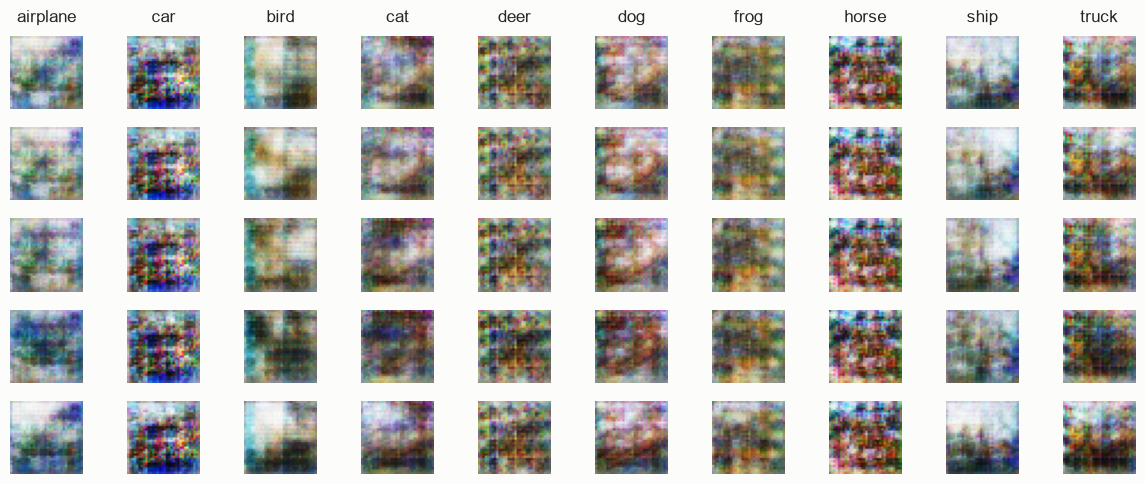

,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.693159,0.693146,0.693267,277.624054


In [15]:
# Generate a sample of images and log FID score into the results dict. 
from torchmetrics.image.fid import FrechetInceptionDistance

generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_1_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_1_results, "experiment_1_ttur")
results

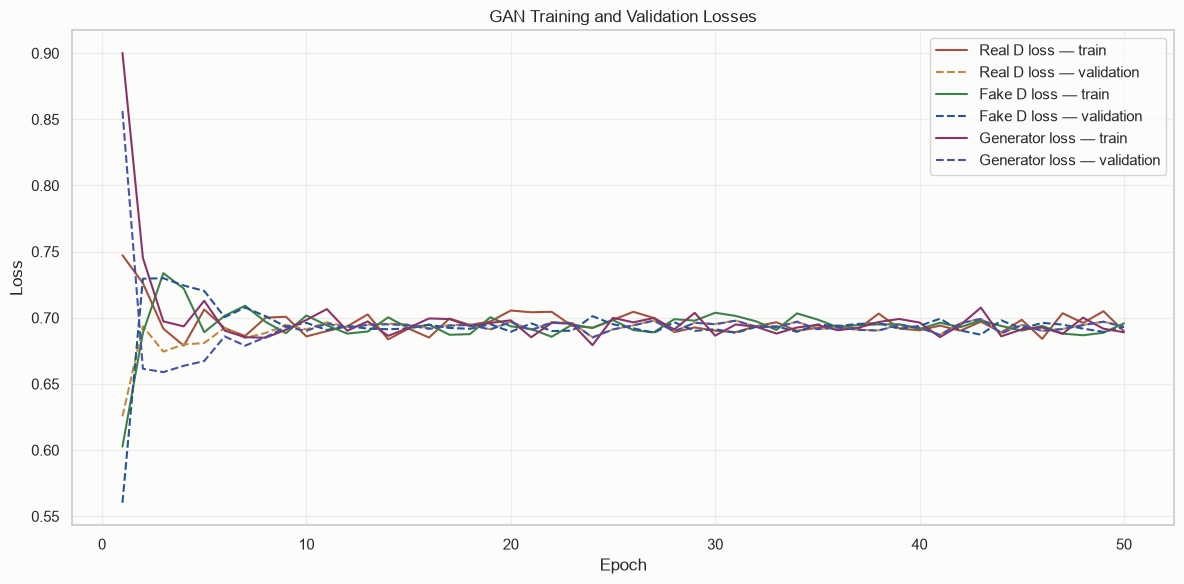

In [16]:
# Plot this experiment's generator/discriminator training and validation loss curves on the same axes.
def plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track):
    plt.figure(figsize=(12, 6))

    tracks = {"Real D loss": real_d_loss_track,"Fake D loss": fake_d_loss_track,"Generator loss": g_loss_track}

    for label, track in tracks.items():
        train_values = track.get("train", [])
        val_values = track.get("val", [])

        if train_values:
            plt.plot(range(1, len(train_values) + 1),train_values,label=f"{label} — train")

        if val_values:
            plt.plot(range(1, len(val_values) + 1),val_values,linestyle="--",label=f"{label} — validation")

    plt.title("GAN Training and Validation Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

TTUR ended with validation generator, real-discriminator, and fake-discriminator losses of `0.693`, `0.693`, and `0.693`; `D(x) = 0.4999` and `D(G(z)) = 0.5000`. The balance is not productive: its fresh FID is `277.624`, `128.69%` worse than the saved baseline FID of `121.398`. The near-`ln(2)` losses and chance-level discriminator outputs indicate a stalled equilibrium rather than an improved generator, so the hypothesis is not supported. The historical blind grid agrees: TTUR scored `0.00`, `3.865` pooled standard errors below the baseline, with none of its 50 saved-grid images recognised as the requested class.


## 5. Experiment 2: Label Smoothing

![One-sided label-smoothing experiment](../../images/gan-experiment-2-label-smoothing.png)

Hypothesis: the baseline's hard 0/1 discriminator targets can make it overconfident and easy to saturate, so one-sided label smoothing (real target 0.9 instead of 1.0) should improve image quality by keeping discriminator gradients informative for longer. The risk is smoothing too much and weakening the discriminator's signal to the generator.

In [17]:
G = generator(noise_dim).to(device)
D = discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

In [18]:
# Train the label-smoothed GAN with the baseline data and optimizer settings.
for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_smooth = torch.full((batch_size,), 0.9).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_smooth) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)




Epoch 0



D(x) = 0.8274
D(G(z)) = 0.0734
D Loss (real): 0.478 | D Loss (fake): 0.092
Generator Loss: 3.386


== Validation ==
D(x) = 0.7941
D(G(z)) = 0.1442
D Loss (real): 0.303 | D Loss (fake): 0.164
Generator Loss: 2.105


Epoch 1



D(x) = 0.6181
D(G(z)) = 0.2219
D Loss (real): 0.621 | D Loss (fake): 0.420
Generator Loss: 1.732


== Validation ==
D(x) = 0.5957
D(G(z)) = 0.3516
D Loss (real): 0.549 | D Loss (fake): 0.451
Generator Loss: 1.113


Epoch 2



...

== Validation ==
D(x) = 0.5222
D(G(z)) = 0.3537
D Loss (real): 0.665 | D Loss (fake): 0.449
Generator Loss: 1.086


Epoch 48



D(x) = 0.6377
D(G(z)) = 0.3712
D Loss (real): 0.524 | D Loss (fake): 0.356
Generator Loss: 1.130


== Validation ==
D(x) = 0.5970
D(G(z)) = 0.3847
D Loss (real): 0.528 | D Loss (fake): 0.497
Generator Loss: 0.990


Epoch 49



D(x) = 0.7347
D(G(z)) = 0.2942
D Loss (real): 0.610 | D Loss (fake): 0.360
Generator Loss: 1.460


== Validation ==
D(x) = 0.5861
D(G(z)) = 0.4116
D Loss (real): 0.545 | D Loss (fake): 0.543
Generator Loss: 0.922


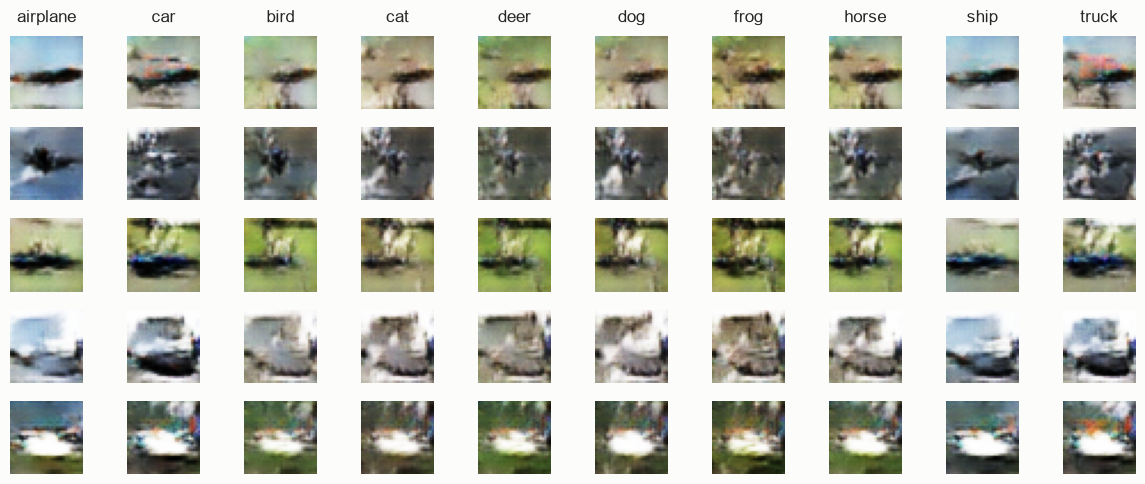

,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.693159,0.693146,0.693267,277.624054
experiment_2_labelsmoothing,NaN,0.921621,0.542916,0.545024,119.925743


In [19]:
# Generate a sample of images and log FID score into the results dict. 
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_2_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_2_results, "experiment_2_labelsmoothing")
results

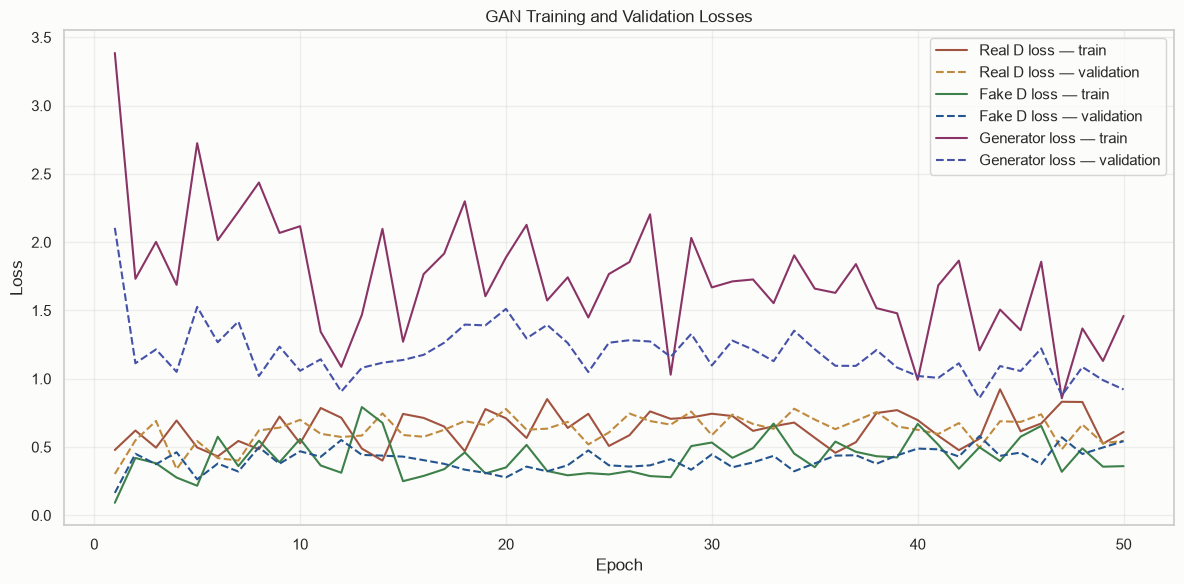

In [20]:
# Plot this experiment's generator/discriminator training and validation loss curves on the same axes.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Label smoothing produced a small fresh improvement: FID decreased from the saved baseline's `121.398` to `119.926`, or `1.21%`. Its final validation generator, real-discriminator, and fake-discriminator losses were `0.922`, `0.545`, and `0.543`, compared with the baseline reference values `0.909`, `0.546`, and `0.552`.

The validation generator loss ranged from approximately `0.859` to `2.105`, so the training signal remained oscillatory rather than becoming consistently smoother. The FID result gives partial support to the hypothesis, but the effect is small relative to the run-to-run variation discussed in Section 3.4. The historical blind grid scored `0.26` against `0.23`, only `0.349` pooled standard errors above the baseline, so it provides no resolved recognisability gain.


## 6. Experiment 3: Spectral Normalization

![Spectral-normalization experiment](../../images/gan-experiment-3-spectral-normalization.png)

Hypothesis: the baseline discriminator's weights are unconstrained and can grow to dominate the generator, so applying spectral normalization to the discriminator's conv layers should improve image quality by capping its Lipschitz constant and stabilizing training. The risk is over-constraining the discriminator so it can no longer distinguish real from fake effectively.

In [15]:
# Build and train a GAN identical to baseline except the discriminator's conv layers are wrapped with spectral normalization.
from torch.nn.utils.parametrizations import spectral_norm

class spectral_discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = spectral_norm(nn.Conv2d(13, 32, 3, 2, 1)) # 32x32 -> 16x16

        self.conv2 = spectral_norm(nn.Conv2d(32, 64, 3, 2, 1)) # 16x16 -> 8x8

        self.conv3 = spectral_norm(nn.Conv2d(64, 128, 3, 2, 1)) # 8x8 -> 4x4

        self.fc_out = spectral_norm(nn.Linear(128*4*4, 1)) 
        # activations
        
        self.leakyrelu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()

        # reg
        self.dropout2d = nn.Dropout2d(0.3)
        
    def forward(self, x, label):
        batch_size = x.size(0)
        label = label.reshape(batch_size, 10, 1, 1).expand(batch_size, 10, 32, 32)
        x = torch.concat((x, label), dim=-3)
        x = self.leakyrelu(self.conv1(x))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.conv2(x))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.conv3(x))
        x = self.dropout2d(x)
        x = x.flatten(start_dim=1)
        x = self.sigmoid(self.fc_out(x))
        return x

In [17]:
G = generator(noise_dim).to(device)
D = spectral_discriminator().to(device)

g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

In [18]:
# Train the spectral-normalized GAN with the baseline data and optimizer settings.
for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)




Epoch 0



D(x) = 0.4808
D(G(z)) = 0.4597
D Loss (real): 0.756 | D Loss (fake): 0.708
Generator Loss: 0.795


== Validation ==
D(x) = 0.5039
D(G(z)) = 0.4374
D Loss (real): 0.706 | D Loss (fake): 0.579
Generator Loss: 0.833


Epoch 1



D(x) = 0.6346
D(G(z)) = 0.3832
D Loss (real): 0.509 | D Loss (fake): 0.548
Generator Loss: 1.005


== Validation ==
D(x) = 0.5637
D(G(z)) = 0.3201
D Loss (real): 0.634 | D Loss (fake): 0.388
Generator Loss: 1.150


Epoch 2



...

== Validation ==
D(x) = 0.5037
D(G(z)) = 0.4985
D Loss (real): 0.686 | D Loss (fake): 0.690
Generator Loss: 0.696


Epoch 48



D(x) = 0.5024
D(G(z)) = 0.5035
D Loss (real): 0.684 | D Loss (fake): 0.715
Generator Loss: 0.687


== Validation ==
D(x) = 0.5028
D(G(z)) = 0.5054
D Loss (real): 0.688 | D Loss (fake): 0.704
Generator Loss: 0.682


Epoch 49



D(x) = 0.4942
D(G(z)) = 0.4892
D Loss (real): 0.695 | D Loss (fake): 0.694
Generator Loss: 0.716


== Validation ==
D(x) = 0.4963
D(G(z)) = 0.4916
D Loss (real): 0.701 | D Loss (fake): 0.677
Generator Loss: 0.710


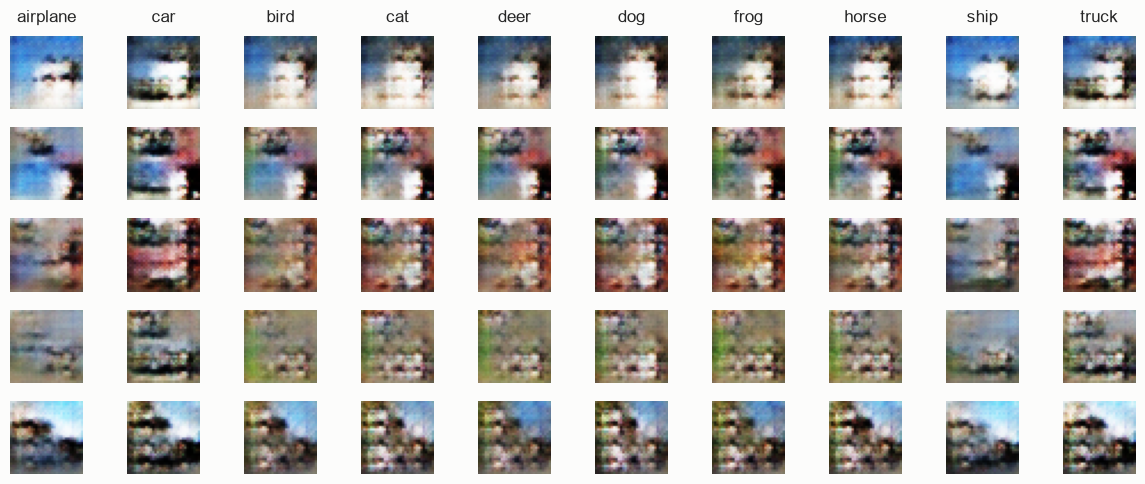

,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.693159,0.693146,0.693267,277.624054
experiment_2_labelsmoothing,NaN,0.921621,0.542916,0.545024,119.925743
experiment_3_spectralnorm,NaN,0.710209,0.676673,0.700640,174.006699


In [19]:
# Generate a sample of images and log FID score into the results dict. 
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_3_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_3_results, "experiment_3_spectralnorm")
results

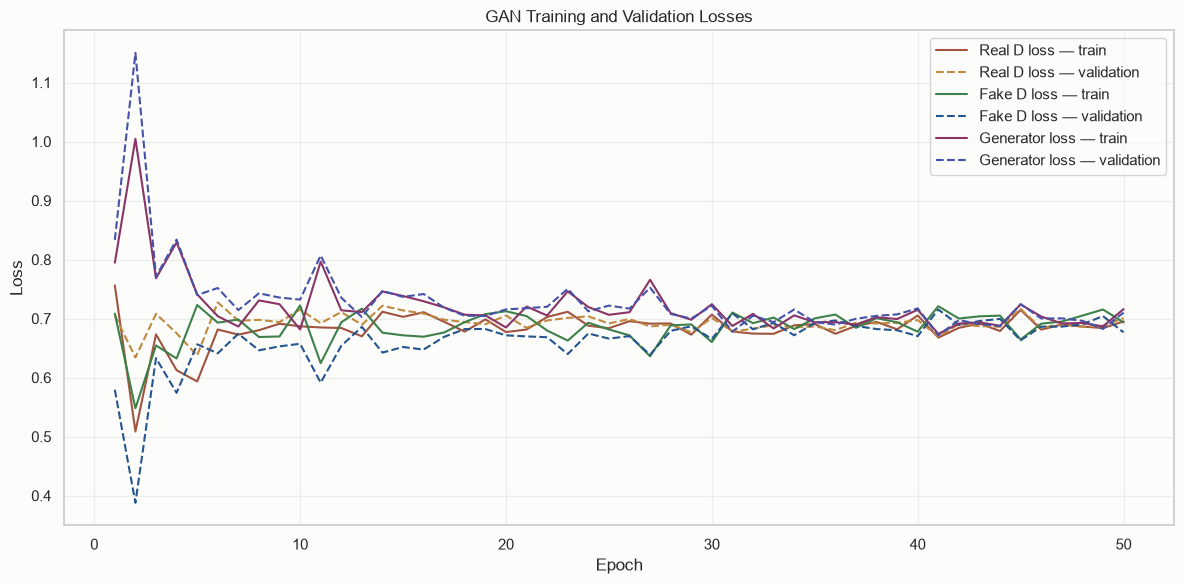

In [20]:
# Plot this experiment's generator/discriminator training and validation loss curves on the same axes.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Spectral normalization did not improve the model. Its fresh FID rose from `121.398` to `174.007`, a `43.34%` deterioration. The final validation generator, real-discriminator, and fake-discriminator losses were `0.710`, `0.701`, and `0.677`, with `D(x) = 0.4963` and `D(G(z)) = 0.4916`.

Those final values are near chance, although the curves did not stay exactly at `0.693` throughout training. Coupled with the poor FID, they are consistent with an over-constrained discriminator that learned little useful separation. The historical blind grid scored `0.08`, `2.118` pooled standard errors below the baseline, so the saved images show the same failure. The hypothesis is not supported.


## 7. Experiment 4: Color vs. Grayscale

![Color-versus-grayscale experiment](../../images/gan-experiment-4-color-vs-grayscale.png)

Hypothesis: converting inputs to grayscale removes color as a distinguishing cue, so recognisability should drop for classes that rely heavily on color but may hold up or improve for shape-dominant classes. This experiment tests the prediction empirically.

In [16]:
# Convert the datasets to grayscale and adjust the generator/discriminator channel counts.

# Release the RGB workers while this section uses its separate grayscale loaders.
shutdown_loader_workers(train_loader)
shutdown_loader_workers(val_loader)

def to_grayscale(images):
    from torchvision.transforms.functional import rgb_to_grayscale
    return {"img": rgb_to_grayscale(images)}

def cached_grayscale_split(cache_dir, total_rows, reference_data):
    candidates = []
    for first_file, shards in complete_cache_shard_sets(cache_dir):
        try:
            first_part = datasets.Dataset.from_file(str(first_file)).with_format('torch')
            if not {'img', 'label'}.issubset(first_part.column_names):
                continue
            first_sample = first_part[0]
            if tuple(first_sample['img'].shape) != (1, 32, 32):
                continue
            if tuple(first_sample['label'].shape) != (10,):
                continue

            candidate = datasets.concatenate_datasets([
                datasets.Dataset.from_file(str(shard)) for shard in shards
            ]).with_format('torch')
            if len(candidate) != total_rows:
                continue

            check_indices = [0, total_rows // 2, total_rows - 1]
            if all(
                torch.equal(candidate[index]['label'], reference_data[index]['label'])
                and torch.equal(
                    candidate[index]['img'],
                    F_t.rgb_to_grayscale(reference_data[index]['img']),
                )
                for index in check_indices
            ):
                newest_mtime = max(shard.stat().st_mtime for shard in shards)
                candidates.append((newest_mtime, candidate))
        except (OSError, ValueError, TypeError, KeyError):
            continue
    return max(candidates, key=lambda item: item[0])[1] if candidates else None

grey_train_data = grey_val_data = grey_test_data = None
if 'cifar_cache_dir' in globals():
    grey_train_data = cached_grayscale_split(cifar_cache_dir, 45000, train_data)
    grey_val_data = cached_grayscale_split(cifar_cache_dir, 5000, val_data)
    grey_test_data = cached_grayscale_split(cifar_cache_dir, 10000, test_data)

if all(split is not None for split in (grey_train_data, grey_val_data, grey_test_data)):
    print(f'using verified cached grayscale CIFAR-10 shards from {cifar_cache_dir}')
else:
    grey_train_data = train_data.map(to_grayscale, input_columns=["img"], batched=True, batch_size=500, num_proc=map_workers)
    grey_val_data = val_data.map(to_grayscale, input_columns=["img"], batched=True, batch_size=500, num_proc=map_workers)
    grey_test_data = test_data.map(to_grayscale, input_columns=["img"], batched=True, batch_size=500, num_proc=map_workers)

G = generator(noise_dim)
D = discriminator()

G.convT3 = nn.ConvTranspose2d(32, 1, 4, 2, 1)
D.conv1 = nn.Conv2d(11, 32, 3, 2, 1)

G = G.to(device)
D = D.to(device)

using verified cached grayscale CIFAR-10 shards from C:\Users\Admin\.cache\huggingface\datasets\uoft-cs___cifar10\plain_text\0.0.0\0b2714987fa478483af9968de7c934580d0bb9a2


In [17]:
# Build and train a GAN identical to baseline except for the single-channel input/output.
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}


grey_train_loader = DataLoader(grey_train_data,batch_size=bs,shuffle=True,
                          num_workers=cpu_cores,pin_memory=True,persistent_workers=True,prefetch_factor=2)
grey_val_loader = DataLoader(grey_val_data,batch_size=bs,shuffle=True,drop_last=True,
                        num_workers=cpu_cores,pin_memory=True,persistent_workers=True,prefetch_factor=2)

In [18]:
# Train the grayscale GAN with the grayscale loaders and baseline optimizer settings.
for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(grey_train_loader):
        
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)
        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(grey_val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)




Epoch 0



D(x) = 0.9177
D(G(z)) = 0.0446
D Loss (real): 0.125 | D Loss (fake): 0.083
Generator Loss: 4.978


== Validation ==
D(x) = 0.9148
D(G(z)) = 0.0578
D Loss (real): 0.109 | D Loss (fake): 0.061
Generator Loss: 3.101


Epoch 1



D(x) = 0.4830
D(G(z)) = 0.4434
D Loss (real): 0.690 | D Loss (fake): 0.736
Generator Loss: 0.842


== Validation ==
D(x) = 0.5006
D(G(z)) = 0.4863
D Loss (real): 0.705 | D Loss (fake): 0.674
Generator Loss: 0.729


Epoch 2



...

== Validation ==
D(x) = 0.5527
D(G(z)) = 0.4712
D Loss (real): 0.602 | D Loss (fake): 0.647
Generator Loss: 0.766


Epoch 48



D(x) = 0.5557
D(G(z)) = 0.3858
D Loss (real): 0.523 | D Loss (fake): 0.588
Generator Loss: 1.022


== Validation ==
D(x) = 0.5614
D(G(z)) = 0.4845
D Loss (real): 0.585 | D Loss (fake): 0.674
Generator Loss: 0.740


Epoch 49



D(x) = 0.6415
D(G(z)) = 0.4229
D Loss (real): 0.644 | D Loss (fake): 0.562
Generator Loss: 0.946


== Validation ==
D(x) = 0.6089
D(G(z)) = 0.5037
D Loss (real): 0.503 | D Loss (fake): 0.712
Generator Loss: 0.698


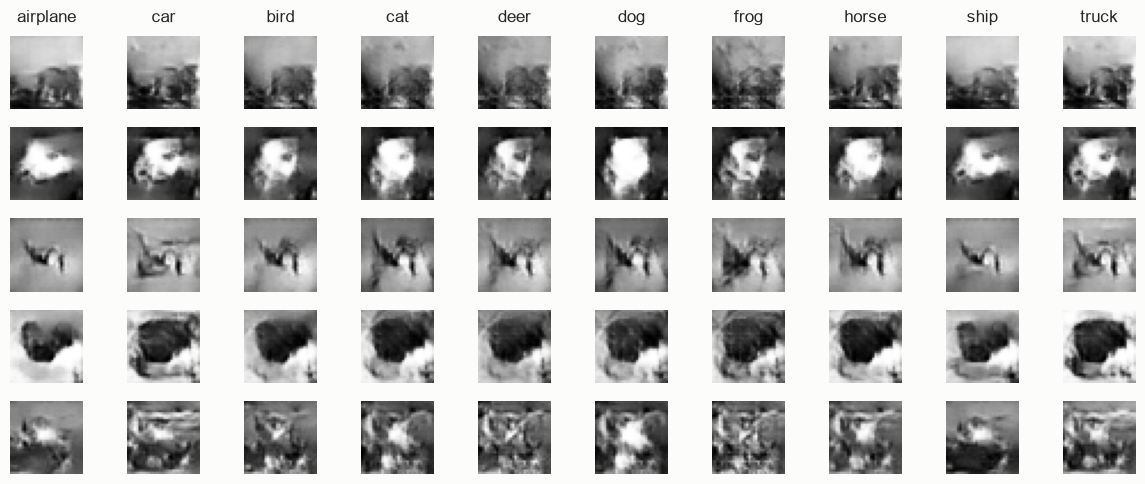

,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.693159,0.693146,0.693267,277.624054
experiment_2_labelsmoothing,NaN,0.921621,0.542916,0.545024,119.925743
experiment_3_spectralnorm,NaN,0.710209,0.676673,0.700640,174.006699
experiment_4_greyscale,NaN,0.697734,0.712309,0.503359,109.257645


In [19]:
# Generate a sample of images and log FID score into the results dict. 
G.eval()
fixed_noise_progression_grid[e + 1] = []

with torch.no_grad():
    fig, ax = plt.subplots(5, 10, figsize=(12, 5))
    for col, a in enumerate(ax[0]):
        a.set_title(f"{classes[col]}", pad=10)

    for idx in range(10):
        one_hot_label = [0] * 10
        one_hot_label[idx] = 1
        one_hot_label = torch.Tensor(one_hot_label).expand(5, -1).to(device)
        noise = val_noise[0:5].to(device)
        per_class_generated_imgs = G(noise, one_hot_label)

        fixed_noise_progression_grid[e + 1].append(
            per_class_generated_imgs[0].detach().cpu().numpy()
        )

        for img in range(per_class_generated_imgs.size(0)):
            ax[img][idx].imshow(F_t.to_pil_image(
                (127.5 * (per_class_generated_imgs[img] + 1)).to(torch.uint8)
            ), cmap='grey')
            ax[img][idx].axis("off")

    plt.tight_layout()
    plt.show()

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in grey_val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        # InceptionV3 expects RGB input, so replicate the grayscale channel.
        real_images_fid = ((real_images + 1) / 2).clamp(0, 1).repeat(1, 3, 1, 1)
        fake_images_fid = ((fake_images + 1) / 2).clamp(0, 1).repeat(1, 3, 1, 1)

        fid.update(real_images_fid, real=True)
        fid.update(fake_images_fid, real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_4_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_4_results, "experiment_4_greyscale")
shutdown_loader_workers(grey_train_loader)
shutdown_loader_workers(grey_val_loader)
results

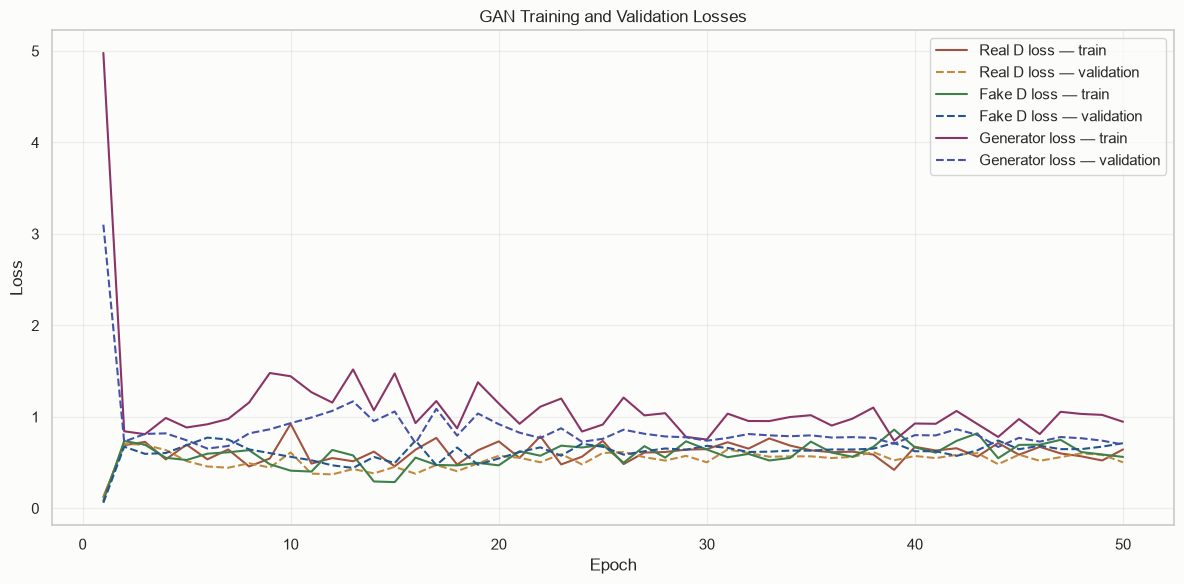

In [20]:
# Plot this experiment's generator/discriminator training and validation loss curves on the same axes.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

In [21]:
# Compare grayscale with the baseline class by class, using the blind grid-review scores.
review_by_class = pd.DataFrame(grid_review["per_class"], index=grid_review["classes"]).T

grayscale_change = pd.DataFrame({
    "baseline": review_by_class.loc["baseline"],
    "grayscale": review_by_class.loc["experiment_4_greyscale"],
})
grayscale_change["change"] = grayscale_change["grayscale"] - grayscale_change["baseline"]
grayscale_change.sort_values("change")

,baseline,grayscale,change
ship,0.5,0.2,-0.3
airplane,0.3,0.1,-0.2
bird,0.2,0.2,0.0
car,0.2,0.2,0.0
deer,0.2,0.2,0.0
dog,0.2,0.2,0.0
frog,0.1,0.1,0.0
cat,0.2,0.2,0.0
horse,0.2,0.2,0.0
truck,0.2,0.2,0.0


### Discussion: Color vs. Grayscale, Empirically

Grayscale achieved a fresh within-grayscale FID of `109.258`. Because it is measured against grayscale-transformed real images, it should not be described as a `10.00%` improvement over the RGB baseline's `121.398`; the two scores target different real-image distributions. Its final validation losses were `0.698` for the generator, `0.503` for real discriminator inputs, and `0.712` for fake inputs.

The historical blind grid score is `0.18` against the baseline's `0.23`, a gap of `-0.620` pooled standard errors. Because these reviews come from saved grids rather than the fresh run, they are supporting context only, but they show no recognisability advantage corresponding to grayscale's low within-representation FID.

In the recorded per-class grid review, only two classes changed: ship fell from `0.5` to `0.2` and airplane from `0.3` to `0.1`; the other eight were unchanged. Those two share blue-grey sky or water backgrounds and are the pair identified as especially similar in `vae_gan_eda.ipynb`, so removing color plausibly removed a useful class cue.

The class review uses only five saved images per class, and it was not repeated for this rerun. The safe conclusion is therefore that the grayscale generator obtained a low FID within its own representation, while the historical recognisability evidence does not show better class-conditioned images; the result cannot establish an advantage over RGB. Grayscale remains excluded from the final RGB selection.


## 8. Experiment 5: Engineered Conditioning Features

![Engineered-conditioning experiment](../../images/gan-experiment-5-engineered-conditioning.png)

Hypothesis: a one-hot label identifies the target class but provides no direct visual attributes. Concatenating each class's mean per-channel color statistics (from `vae_gan_eda.ipynb` Section 5) with the one-hot vector may give both networks a richer conditioning signal. The experiment tests whether those features add useful information or are redundant with the class label.

In [16]:
# Compute each class's mean RGB values and append them to its one-hot label.
class_rgb_sums = torch.zeros(len(classes), 3)
class_counts = torch.zeros(len(classes))

for batch in train_loader:
    images = batch["img"].float()
    class_ids = batch["label"].argmax(dim=1)
    image_rgb_means = images.mean(dim=(2, 3))
    class_rgb_sums.index_add_(0, class_ids, image_rgb_means)
    class_counts.index_add_(0, class_ids, torch.ones_like(class_ids, dtype=torch.float32))

class_rgb_vectors = class_rgb_sums / class_counts.unsqueeze(1)
shutdown_loader_workers(train_loader)
shutdown_loader_workers(val_loader)

def attach_rgb_vector(labels, rgb_vectors):
    import torch
    labels = torch.as_tensor(labels, dtype=torch.float32)
    class_ids = labels.argmax(dim=1)
    rgb_vectors = torch.as_tensor(rgb_vectors, dtype=torch.float32)
    augmented_labels = torch.cat((labels, rgb_vectors[class_ids]), dim=1)
    return {"label": augmented_labels.tolist()}

rgb_vector_values = class_rgb_vectors.tolist()
def cached_rgb_conditioned_split(cache_dir, total_rows, reference_data):
    candidates = []
    for first_file, shards in complete_cache_shard_sets(cache_dir):
        try:
            first_part = datasets.Dataset.from_file(str(first_file))
            if not {'img', 'label'}.issubset(first_part.column_names):
                continue
            label_leaf = getattr(getattr(first_part.features['label'], 'feature', None), 'dtype', None)
            if label_leaf not in {'float32', 'float64'}:
                continue
            first_sample = first_part.with_format('torch')[0]
            if tuple(first_sample['img'].shape) != (3, 32, 32):
                continue
            if tuple(first_sample['label'].shape) != (13,):
                continue

            candidate = datasets.concatenate_datasets([
                datasets.Dataset.from_file(str(shard)) for shard in shards
            ]).with_format('torch')
            if len(candidate) != total_rows:
                continue

            check_indices = [0, total_rows // 2, total_rows - 1]
            compatible = True
            for index in check_indices:
                cached_sample = candidate[index]
                reference_sample = reference_data[index]
                class_id = int(reference_sample['label'].argmax())
                compatible &= torch.equal(cached_sample['img'], reference_sample['img'])
                compatible &= torch.equal(cached_sample['label'][:10], reference_sample['label'].float())
                compatible &= torch.allclose(
                    cached_sample['label'][10:], class_rgb_vectors[class_id], atol=1e-6, rtol=0
                )
            if compatible:
                newest_mtime = max(shard.stat().st_mtime for shard in shards)
                candidates.append((newest_mtime, candidate))
        except (OSError, ValueError, TypeError, KeyError):
            continue
    return max(candidates, key=lambda item: item[0])[1] if candidates else None

rgb_train_data = rgb_val_data = None
if 'cifar_cache_dir' in globals():
    rgb_train_data = cached_rgb_conditioned_split(cifar_cache_dir, 45000, train_data)
    rgb_val_data = cached_rgb_conditioned_split(cifar_cache_dir, 5000, val_data)

if rgb_train_data is not None and rgb_val_data is not None:
    print(f'using verified cached RGB-conditioned CIFAR-10 shards from {cifar_cache_dir}')
else:
    rgb_train_data = train_data.map(attach_rgb_vector, input_columns=["label"], batched=True, batch_size=500, num_proc=map_workers, fn_kwargs={"rgb_vectors": rgb_vector_values}).with_format("torch")
    rgb_val_data = val_data.map(attach_rgb_vector, input_columns=["label"], batched=True, batch_size=500, num_proc=map_workers, fn_kwargs={"rgb_vectors": rgb_vector_values}).with_format("torch")

G = generator(noise_dim)
D = discriminator()

G.proj = nn.Linear(noise_dim + 13, 128 * 4 * 4)
D.conv1 = nn.Conv2d(16, 32, 3, 2, 1)

# Feed the three auxiliary values into D as constant feature maps while preserving its original 10-label forward method.
def prepare_rgb_conditioning(module, inputs):
    images, labels = inputs
    auxiliary_maps = labels[:, 10:].reshape(-1, 3, 1, 1).expand(-1, -1, 32, 32)
    return torch.cat((images, auxiliary_maps), dim=1), labels[:, :10]

D.register_forward_pre_hook(prepare_rgb_conditioning)
G = G.to(device)
D = D.to(device)

rgb_train_loader = DataLoader(rgb_train_data, batch_size=bs, shuffle=True,
                              num_workers=cpu_cores, pin_memory=True,
                              persistent_workers=True, prefetch_factor=2)
rgb_val_loader = DataLoader(rgb_val_data, batch_size=bs, shuffle=True, drop_last=True,
                            num_workers=cpu_cores, pin_memory=True,
                            persistent_workers=True, prefetch_factor=2)

class_rgb_vectors_df = pd.DataFrame(
    class_rgb_vectors.numpy(), index=classes, columns=["mean_r", "mean_g", "mean_b"]
)
class_rgb_vectors_df

using verified cached RGB-conditioned CIFAR-10 shards from C:\Users\Admin\.cache\huggingface\datasets\uoft-cs___cifar10\plain_text\0.0.0\0b2714987fa478483af9968de7c934580d0bb9a2


,mean_r,mean_g,mean_b
airplane,0.053313,0.122054,0.178764
car,-0.057368,-0.090589,-0.105671
bird,-0.020485,-0.015324,-0.149567
cat,-0.006809,-0.085950,-0.168843
deer,-0.056804,-0.069991,-0.243451
dog,0.000925,-0.070781,-0.166345
frog,-0.060396,-0.123451,-0.309783
horse,0.003357,-0.040596,-0.166429
ship,-0.018714,0.051434,0.110057
truck,-0.001329,-0.028078,-0.042958


In [17]:
# Build and train a GAN identical to baseline except the conditioning input is [one-hot label, auxiliary color-stats vector] instead of one-hot alone.
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(rgb_train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(rgb_val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0



D(x) = 0.5136
D(G(z)) = 0.3902
D Loss (real): 0.892 | D Loss (fake): 0.666
Generator Loss: 1.118


== Validation ==
D(x) = 0.6007
D(G(z)) = 0.4593
D Loss (real): 0.534 | D Loss (fake): 0.638
Generator Loss: 0.812


Epoch 1



D(x) = 0.6381
D(G(z)) = 0.3478
D Loss (real): 0.363 | D Loss (fake): 0.755
Generator Loss: 1.293


== Validation ==
D(x) = 0.6219
D(G(z)) = 0.4689
D Loss (real): 0.515 | D Loss (fake): 0.697
Generator Loss: 0.859


Epoch 2



...

== Validation ==
D(x) = 0.5942
D(G(z)) = 0.4107
D Loss (real): 0.538 | D Loss (fake): 0.550
Generator Loss: 0.949


Epoch 48



D(x) = 0.6001
D(G(z)) = 0.5836
D Loss (real): 0.311 | D Loss (fake): 0.725
Generator Loss: 0.624


== Validation ==
D(x) = 0.6581
D(G(z)) = 0.4919
D Loss (real): 0.431 | D Loss (fake): 0.702
Generator Loss: 0.742


Epoch 49



D(x) = 0.6080
D(G(z)) = 0.4038
D Loss (real): 0.595 | D Loss (fake): 0.419
Generator Loss: 1.066


== Validation ==
D(x) = 0.6392
D(G(z)) = 0.4361
D Loss (real): 0.463 | D Loss (fake): 0.593
Generator Loss: 0.863


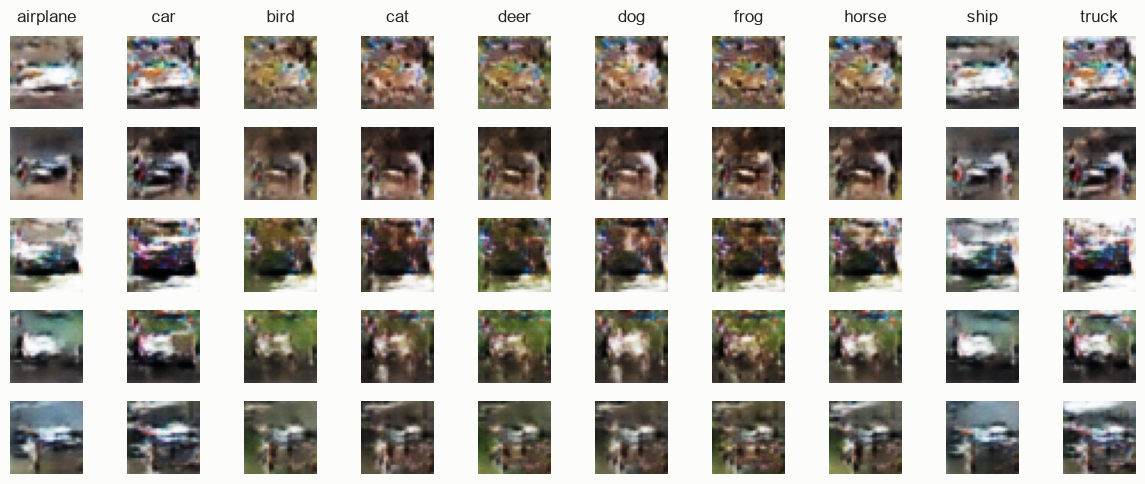

,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.693159,0.693146,0.693267,277.624054
experiment_2_labelsmoothing,NaN,0.921621,0.542916,0.545024,119.925743
experiment_3_spectralnorm,NaN,0.710209,0.676673,0.700640,174.006699
experiment_4_greyscale,NaN,0.697734,0.712309,0.503359,109.257645
experiment_5_engineered_conditioning,NaN,0.863449,0.592940,0.462868,123.245125


In [18]:
# Generate a sample of images, and log FID + other metrics into the results dict.
def generate_rgb_conditioned_class_images(G, n, e):
    G.eval()
    fixed_noise_progression_grid[e + 1] = []

    with torch.no_grad():
        fig, ax = plt.subplots(n, 10, figsize=(12, 5))
        for col, a in enumerate(ax[0]):
            a.set_title(f"{classes[col]}", pad=10)

        for idx in range(10):
            one_hot_label = [0] * 10
            one_hot_label[idx] = 1
            conditioned_label = torch.cat((
                torch.tensor(one_hot_label, dtype=torch.float32),
                class_rgb_vectors[idx],
            )).expand(n, -1).to(device)
            noise = val_noise[0:n].to(device)
            per_class_generated_imgs = G(noise, conditioned_label)

            fixed_noise_progression_grid[e + 1].append(
                per_class_generated_imgs[0].detach().cpu().numpy()
            )

            for img in range(per_class_generated_imgs.size(0)):
                ax[img][idx].imshow(F_t.to_pil_image(
                    (127.5 * (per_class_generated_imgs[img] + 1)).to(torch.uint8)
                ))
                ax[img][idx].axis("off")

        plt.tight_layout()
        plt.show()

generate_rgb_conditioned_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in rgb_val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_5_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_5_results, "experiment_5_engineered_conditioning")
shutdown_loader_workers(rgb_train_loader)
shutdown_loader_workers(rgb_val_loader)
results

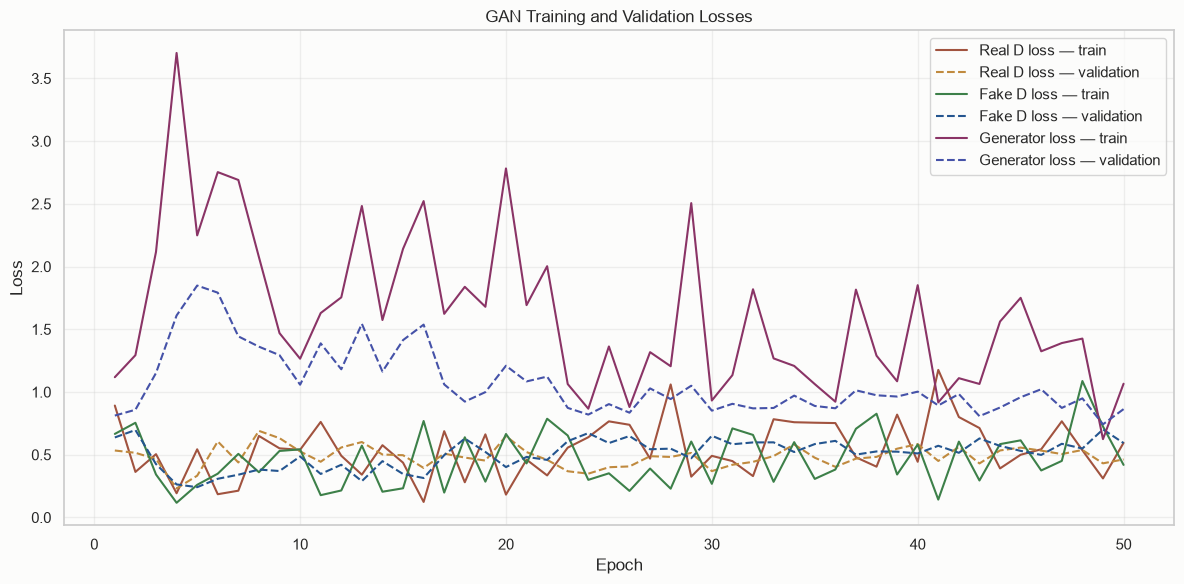

In [19]:
# Plot this experiment's generator/discriminator loss curves 
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Engineered RGB conditioning did not improve fresh FID: it increased from `121.398` to `123.245`, a `1.52%` deterioration. The final validation generator, real-discriminator, and fake-discriminator losses were `0.863`, `0.463`, and `0.593`; validation generator loss ranged from about `0.742` to `1.849`, so the added features did not remove oscillation.

The fresh result does not support the hypothesis that class-mean RGB values add useful information beyond the one-hot labels. The historical blind grid scored this setting `0.35` against the baseline's `0.23`, a suggestive but unresolved gap of `1.334` pooled standard errors. That recorded review may indicate stronger class cues in its saved run, but it is not evidence of a fresh FID improvement here.


## 9. Experiment 6: Data Augmentation

![Real-image augmentation experiment](../../images/gan-experiment-6-data-augmentation.png)

Hypothesis: augmentation (e.g. random horizontal flip) exposes the discriminator to more visual variation per class without new data, which should improve image quality by making the discriminator generalize instead of memorizing exact training images (a stronger discriminator gives the generator a better training signal). The risk is that some flips are semantically wrong for a class and could confuse conditioning instead of helping it.

In [16]:
# Define an augmentation pipeline (e.g. random horizontal flip) applied to the training set only.
augmentation_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=5,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05),
        )
    ], p=0.4),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.5),
        )
    ], p=0.15),
])

In [21]:
# Build and train a GAN identical to baseline except the discriminator's real-image inputs are passed through the augmentation pipeline.
G = generator(noise_dim).to(device)
D = discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = augmentation_pipeline(sample['img'].to(device, non_blocking=True))
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0



D(x) = 0.6284
D(G(z)) = 0.3951
D Loss (real): 0.688 | D Loss (fake): 0.755
Generator Loss: 1.122


== Validation ==
D(x) = 0.6053
D(G(z)) = 0.4449
D Loss (real): 0.567 | D Loss (fake): 0.612
Generator Loss: 0.852


Epoch 1



D(x) = 0.5570
D(G(z)) = 0.4720
D Loss (real): 0.862 | D Loss (fake): 0.657
Generator Loss: 0.860


== Validation ==
D(x) = 0.5878
D(G(z)) = 0.4442
D Loss (real): 0.551 | D Loss (fake): 0.605
Generator Loss: 0.842


Epoch 2



...

== Validation ==
D(x) = 0.5564
D(G(z)) = 0.4025
D Loss (real): 0.609 | D Loss (fake): 0.532
Generator Loss: 0.952


Epoch 48



D(x) = 0.5535
D(G(z)) = 0.3054
D Loss (real): 0.650 | D Loss (fake): 0.754
Generator Loss: 1.415


== Validation ==
D(x) = 0.5579
D(G(z)) = 0.3892
D Loss (real): 0.602 | D Loss (fake): 0.507
Generator Loss: 0.983


Epoch 49



D(x) = 0.7208
D(G(z)) = 0.2580
D Loss (real): 0.805 | D Loss (fake): 0.342
Generator Loss: 1.643


== Validation ==
D(x) = 0.5662
D(G(z)) = 0.3847
D Loss (real): 0.597 | D Loss (fake): 0.503
Generator Loss: 1.005


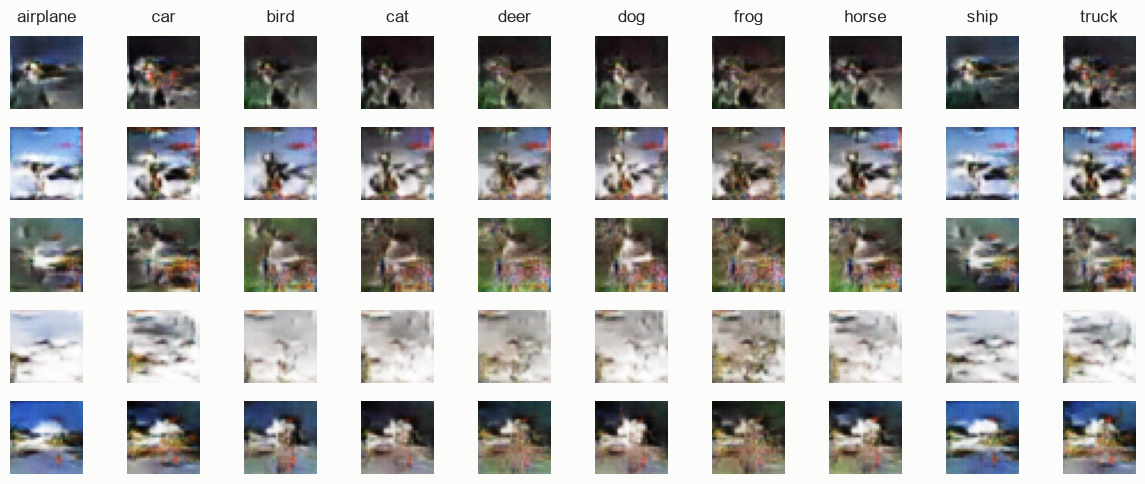

,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.693159,0.693146,0.693267,277.624054
experiment_2_labelsmoothing,NaN,0.921621,0.542916,0.545024,119.925743
experiment_3_spectralnorm,NaN,0.710209,0.676673,0.700640,174.006699
experiment_4_greyscale,NaN,0.697734,0.712309,0.503359,109.257645
experiment_5_engineered_conditioning,NaN,0.863449,0.592940,0.462868,123.245125
experiment_6_augmentation,NaN,1.005333,0.502953,0.596925,117.603127


In [22]:
# Generate a sample of images, and log FID + other metrics into the results dict.
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_6_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_6_results, "experiment_6_augmentation")
results

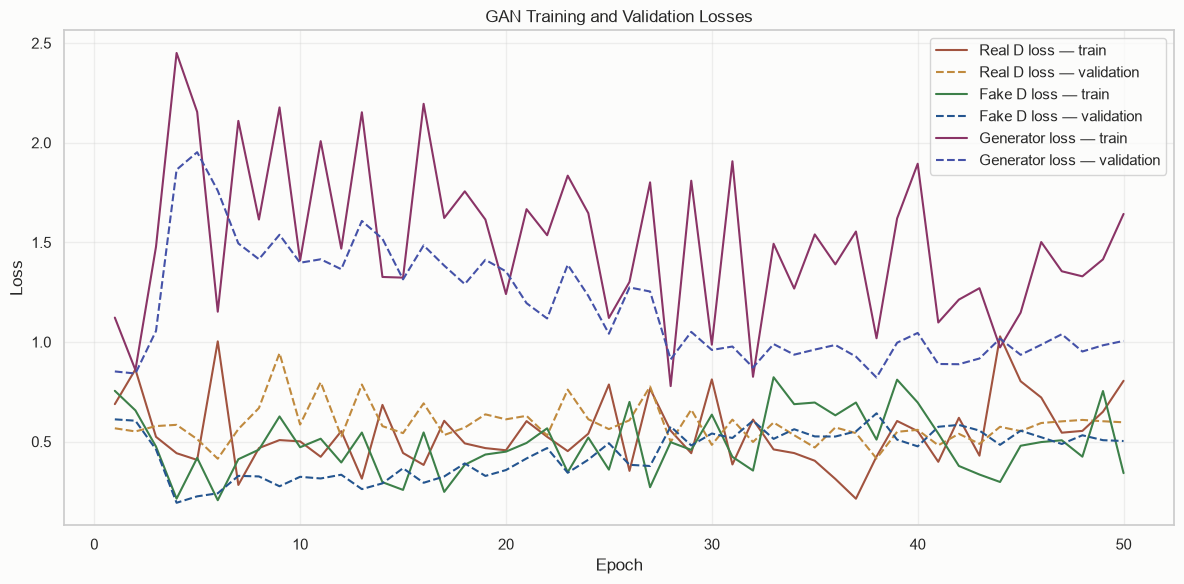

In [23]:
# Plot this experiment's generator/discriminator loss curves 
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Soft augmentation achieved the best eligible non-grayscale FID in the fresh ablation, reducing the saved baseline from `121.398` to `117.603`, an improvement of `3.13%`. Its final validation generator, real-discriminator, and fake-discriminator losses were `1.005`, `0.597`, and `0.503`; validation generator loss ranged from `0.822` to `1.952`, so the curves remained oscillatory.

The lower FID supports the hypothesis that mild variation in the discriminator's real inputs can improve generalisation within this run, and it is why Section 14 selects this setting. The historical blind grid scored augmentation `0.27` against the baseline's `0.23`, only `0.462` pooled standard errors higher, so it shows no resolved recognisability advantage. The standalone retrain later reaches FID `123.503` and a fresh manual score of `0.165`, so the ablation gain does not reproduce reliably.


## 10. Experiment 7: Auxiliary Classifier GAN (AC-GAN)

![AC-GAN experiment](../../images/gan-experiment-7-acgan.png)

Hypothesis: requiring the discriminator to predict both source authenticity and the semantic class of real and generated images should give the generator a stronger class-specific training signal, improving visible separation between classes and raising recognisability - checked against the risk that the auxiliary classification objective dominates adversarial learning.

In [24]:
# Create an AC-GAN discriminator with shared image features, a real/fake head, and a class head.
class acgan_discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.3),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.3),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.3),
        )
        self.real_fake_out = nn.Linear(128*4*4, 1)
        self.class_out = nn.Linear(128*4*4, len(classes))
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        features = self.features(x)
        features = features.flatten(start_dim=1)
        real_fake_pred = self.sigmoid(self.real_fake_out(features))
        class_logits = self.class_out(features)
        return real_fake_pred, class_logits

In [25]:
# Train on the base train_loader and validate with val_loader using the baseline optimizer settings.
G = generator(noise_dim).to(device)
D = acgan_discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
class_criterion = nn.CrossEntropyLoss()
lambda_class = 1.0
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)
        class_targets = label.argmax(dim=1)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred, real_class_pred = D(img)
        real_source_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1
        real_class_loss = class_criterion(real_class_pred, class_targets)
        real_d_loss = real_source_loss + lambda_class * real_class_loss

        fake_d_pred, fake_class_pred = D(generated_img.detach())
        fake_source_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0
        fake_class_loss = class_criterion(fake_class_pred, class_targets)
        fake_d_loss = fake_source_loss + lambda_class * fake_class_loss

        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred, g_class_pred = D(generated_img) # uses the new discriminator
        g_adversarial_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_class_loss = class_criterion(g_class_pred, class_targets)
        g_loss = g_adversarial_loss + lambda_class * g_class_loss
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred, _ = D(img)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    print(f"Class loss (real/fake): {real_class_loss:.3f} / {fake_class_loss:.3f}")
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)
        class_targets = label.argmax(dim=1)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred, v_real_class_pred = D(img)
                        
            v_fake_pred, v_fake_class_pred = D(v_generated_img)

            v_real_class_loss = class_criterion(v_real_class_pred, class_targets)
            v_fake_class_loss = class_criterion(v_fake_class_pred, class_targets)
            v_real_d_loss = criterion(v_real_pred, target_ones) + lambda_class * v_real_class_loss
            v_fake_d_loss = criterion(v_fake_pred, target_zeros) + lambda_class * v_fake_class_loss
            v_g_loss = criterion(v_fake_pred, target_ones) + lambda_class * v_fake_class_loss

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0



D(x) = 0.7291
D(G(z)) = 0.1114
D Loss (real): 2.194 | D Loss (fake): 2.246
Generator Loss: 4.907
Class loss (real/fake): 1.927 / 1.995


== Validation ==
D(x) = 0.8136
D(G(z)) = 0.2512
D Loss (real): 2.014 | D Loss (fake): 2.334
Generator Loss: 3.501


Epoch 1



D(x) = 0.4383
D(G(z)) = 0.3920
D Loss (real): 2.638 | D Loss (fake): 0.803
Generator Loss: 1.356
Class loss (real/fake): 1.896 / 0.295


== Validation ==
D(x) = 0.5774
D(G(z)) = 0.4454
D Loss (real): 2.464 | D Loss (fake): 0.830
Generator Loss: 1.059


Epoch 2



...

== Validation ==
D(x) = 0.4939
D(G(z)) = 0.4202
D Loss (real): 1.855 | D Loss (fake): 0.558
Generator Loss: 0.884


Epoch 48



D(x) = 0.5483
D(G(z)) = 0.4421
D Loss (real): 1.416 | D Loss (fake): 0.697
Generator Loss: 0.894
Class loss (real/fake): 0.786 / 0.034


== Validation ==
D(x) = 0.4872
D(G(z)) = 0.4270
D Loss (real): 1.626 | D Loss (fake): 0.571
Generator Loss: 0.869


Epoch 49



D(x) = 0.5153
D(G(z)) = 0.4614
D Loss (real): 2.017 | D Loss (fake): 0.704
Generator Loss: 0.839
Class loss (real/fake): 1.266 / 0.035


== Validation ==
D(x) = 0.4725
D(G(z)) = 0.4148
D Loss (real): 1.810 | D Loss (fake): 0.551
Generator Loss: 0.902


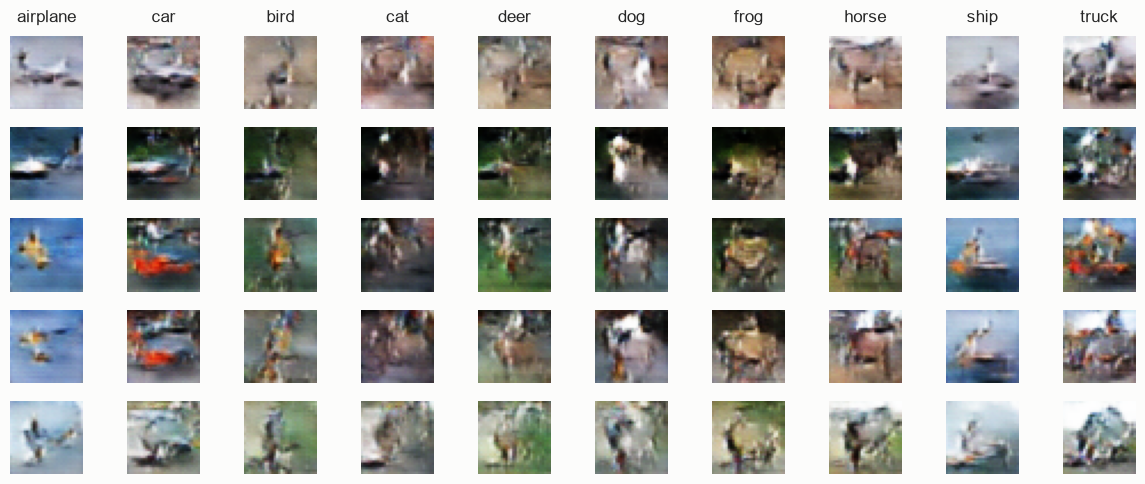

,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.693159,0.693146,0.693267,277.624054
experiment_2_labelsmoothing,NaN,0.921621,0.542916,0.545024,119.925743
experiment_3_spectralnorm,NaN,0.710209,0.676673,0.700640,174.006699
experiment_4_greyscale,NaN,0.697734,0.712309,0.503359,109.257645
experiment_5_engineered_conditioning,NaN,0.863449,0.592940,0.462868,123.245125
experiment_6_augmentation,NaN,1.005333,0.502953,0.596925,117.603127
experiment_7_acgan,NaN,0.901835,0.551414,1.809730,122.709625


In [26]:
# Calculate FID, add the experiment to the results dataframe, and generate five samples per class.
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_7_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_7_results, "experiment_7_acgan")
results

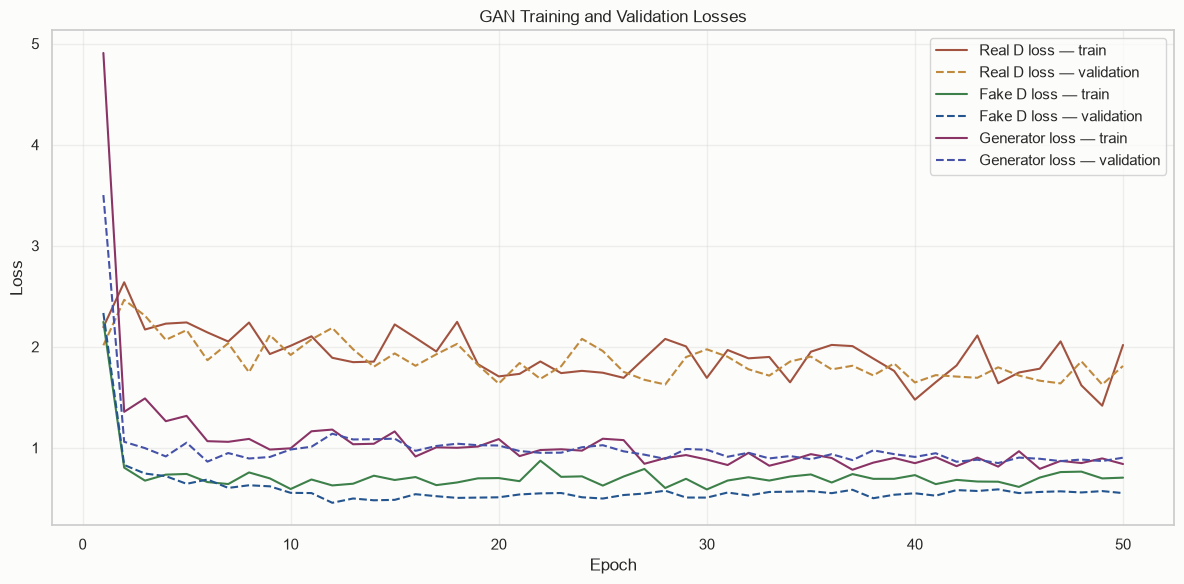

In [27]:
# Plot losses.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

AC-GAN's fresh FID is `122.710`, `1.08%` worse than the saved baseline rather than an improvement. Its final validation generator, real-discriminator, and fake-discriminator losses were `0.902`, `1.810`, and `0.551`; the generator, real-discriminator, and fake-discriminator losses each include an auxiliary cross-entropy term, so none of their magnitudes is directly comparable with the corresponding baseline-experiment loss.

The recorded fixed-noise review still separates AC-GAN from every other saved grid: `0.48` against the baseline's `0.23`, a gap of `2.706` pooled standard errors and the only resolved positive review gap. That is historical qualitative evidence for stronger class cues, not a new review of this rerun. The disagreement between a slightly worse fresh FID and the strongest recorded class recognisability is a reminder that the auxiliary objective targets label fidelity more directly than FID does.


## 11. Experiment 8: Deeper Architecture

![Deeper-architecture experiment](../../images/gan-experiment-8-deeper-architecture.png)

Hypothesis: adding same-resolution convolutional refinement layers between the existing upsampling and downsampling stages should give both networks more capacity to learn useful local features and improve FID, while retaining the DCGAN spatial pathway and shallow fully connected structure. The main risk is that the extra depth makes the adversarial optimization less stable without adding useful class-specific information.

In [28]:
# Define deeper generator and discriminator classes without adding extra fully connected layers.
class deeper_generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.proj = nn.Linear(noise_dim + 10, 128*4*4)
        self.bn_proj = nn.BatchNorm1d(128*4*4)

        # Keep 4x4, then upsample to 8x8.
        self.convT_same1 = nn.ConvTranspose2d(128, 128, 3, 1, 1)
        self.bn_same1 = nn.BatchNorm2d(128)
        self.convT_up1 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.bn_up1 = nn.BatchNorm2d(64)

        # Keep 8x8, then upsample to 16x16.
        self.convT_same2 = nn.ConvTranspose2d(64, 64, 3, 1, 1)
        self.bn_same2 = nn.BatchNorm2d(64)
        self.convT_up2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.bn_up2 = nn.BatchNorm2d(32)

        # Keep 16x16, then upsample to the 32x32 RGB output.
        self.convT_same3 = nn.ConvTranspose2d(32, 32, 3, 1, 1)
        self.bn_same3 = nn.BatchNorm2d(32)
        self.convT_out = nn.ConvTranspose2d(32, 3, 4, 2, 1)

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, noise, label):
        x = torch.concat((noise, label), dim=-1)
        x = self.relu(self.bn_proj(self.proj(x)))
        x = x.reshape(-1, 128, 4, 4)

        x = self.relu(self.bn_same1(self.convT_same1(x)))
        x = self.relu(self.bn_up1(self.convT_up1(x)))
        x = self.relu(self.bn_same2(self.convT_same2(x)))
        x = self.relu(self.bn_up2(self.convT_up2(x)))
        x = self.relu(self.bn_same3(self.convT_same3(x)))
        return self.tanh(self.convT_out(x))


class deeper_discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Downsample 32x32 -> 16x16, then keep 16x16.
        self.conv_down1 = nn.Conv2d(13, 32, 3, 2, 1)
        self.conv_same1 = nn.Conv2d(32, 32, 3, 1, 1)
        self.bn_same1 = nn.BatchNorm2d(32)

        # Downsample 16x16 -> 8x8, then keep 8x8.
        self.conv_down2 = nn.Conv2d(32, 64, 3, 2, 1)
        self.bn_down2 = nn.BatchNorm2d(64)
        self.conv_same2 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn_same2 = nn.BatchNorm2d(64)

        # Downsample 8x8 -> 4x4, then keep the final 4x4 map.
        self.conv_down3 = nn.Conv2d(64, 128, 3, 2, 1)
        self.bn_down3 = nn.BatchNorm2d(128)
        self.conv_same3 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn_same3 = nn.BatchNorm2d(128)

        self.fc_out = nn.Linear(128*4*4, 1)
        self.leakyrelu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()
        self.dropout2d = nn.Dropout2d(0.3)

    def forward(self, x, label):
        batch_size = x.size(0)
        label = label.reshape(batch_size, 10, 1, 1).expand(batch_size, 10, 32, 32)
        x = torch.concat((x, label), dim=-3)

        x = self.leakyrelu(self.conv_down1(x))
        x = self.leakyrelu(self.bn_same1(self.conv_same1(x)))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn_down2(self.conv_down2(x)))
        x = self.leakyrelu(self.bn_same2(self.conv_same2(x)))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn_down3(self.conv_down3(x)))
        x = self.leakyrelu(self.bn_same3(self.conv_same3(x)))
        x = self.dropout2d(x)

        x = x.flatten(start_dim=1)
        return self.sigmoid(self.fc_out(x))

In [29]:
# Train the deeper GAN with the same loaders, losses, and optimizer settings as the baseline.
G = deeper_generator(noise_dim).to(device)
D = deeper_discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50 

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0



D(x) = 0.5611
D(G(z)) = 0.1295
D Loss (real): 0.522 | D Loss (fake): 0.660
Generator Loss: 2.480


== Validation ==
D(x) = 0.5216
D(G(z)) = 0.4151
D Loss (real): 0.758 | D Loss (fake): 0.562
Generator Loss: 0.941


Epoch 1



D(x) = 0.8466
D(G(z)) = 0.1704
D Loss (real): 0.509 | D Loss (fake): 0.065
Generator Loss: 2.164


== Validation ==
D(x) = 0.7108
D(G(z)) = 0.2246
D Loss (real): 0.393 | D Loss (fake): 0.259
Generator Loss: 1.545


Epoch 2



...

== Validation ==
D(x) = 0.6034
D(G(z)) = 0.4818
D Loss (real): 0.527 | D Loss (fake): 0.682
Generator Loss: 0.763


Epoch 48



D(x) = 0.7441
D(G(z)) = 0.5188
D Loss (real): 0.628 | D Loss (fake): 0.531
Generator Loss: 0.708


== Validation ==
D(x) = 0.5469
D(G(z)) = 0.4403
D Loss (real): 0.627 | D Loss (fake): 0.599
Generator Loss: 0.856


Epoch 49



D(x) = 0.6919
D(G(z)) = 0.6483
D Loss (real): 0.236 | D Loss (fake): 0.894
Generator Loss: 0.474


== Validation ==
D(x) = 0.5418
D(G(z)) = 0.4744
D Loss (real): 0.639 | D Loss (fake): 0.670
Generator Loss: 0.780


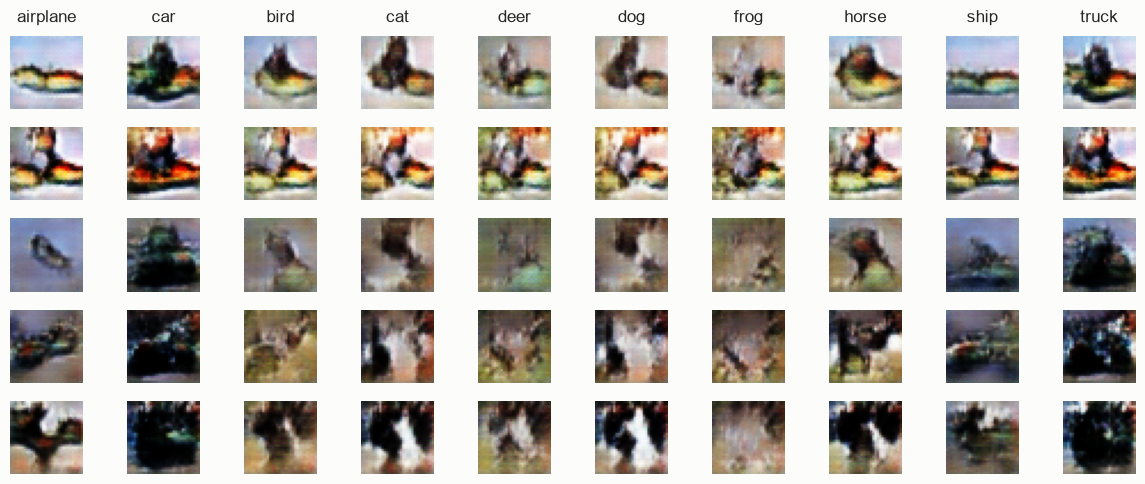

,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.693159,0.693146,0.693267,277.624054
experiment_2_labelsmoothing,NaN,0.921621,0.542916,0.545024,119.925743
experiment_3_spectralnorm,NaN,0.710209,0.676673,0.700640,174.006699
experiment_4_greyscale,NaN,0.697734,0.712309,0.503359,109.257645
experiment_5_engineered_conditioning,NaN,0.863449,0.592940,0.462868,123.245125
experiment_6_augmentation,NaN,1.005333,0.502953,0.596925,117.603127
experiment_7_acgan,NaN,0.901835,0.551414,1.809730,122.709625
experiment_8_deeper_architecture,NaN,0.780252,0.669503,0.639291,138.292236


In [30]:
# Generate five samples per class, calculate FID, and add the experiment metrics to the results dataframe.
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_8_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_8_results, "experiment_8_deeper_architecture")
results

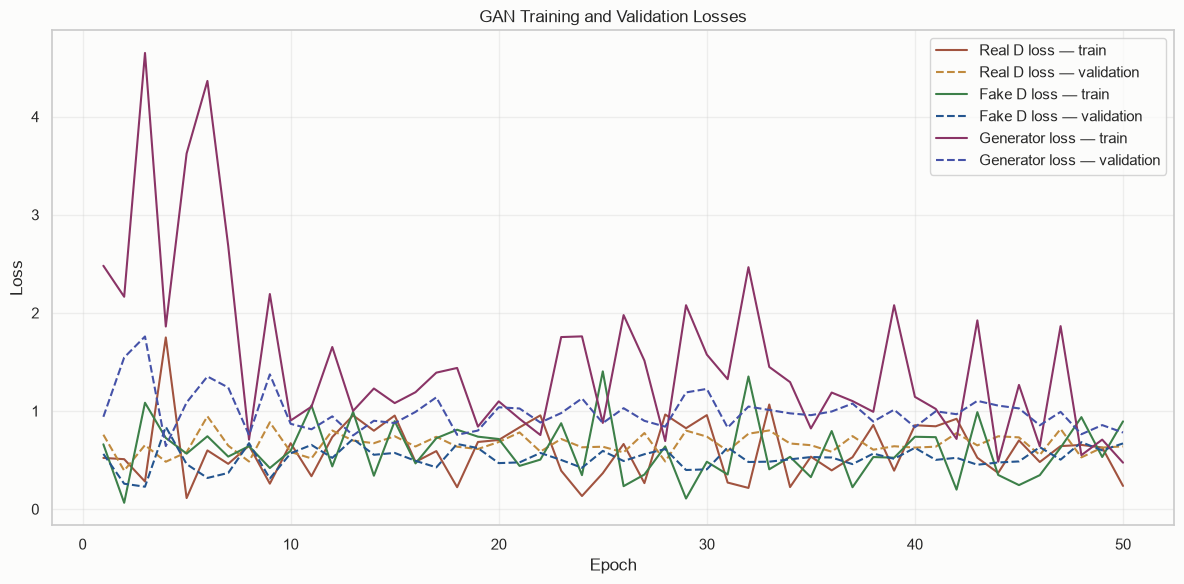

In [31]:
# Plot losses.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

The deeper architecture worsened fresh FID from `121.398` to `138.292`, an increase of `13.92%`. Its final validation generator, real-discriminator, and fake-discriminator losses were `0.780`, `0.639`, and `0.670`, while both training and validation curves contained substantial spikes. The added refinement layers therefore increased optimisation difficulty without improving the generated distribution, so the hypothesis is not supported.

The historical blind grid scored this model `0.26` against the baseline's `0.23`, a gap of `0.349` pooled standard errors. That saved-grid review does not resolve the deterioration reported by fresh FID, and no new subjective grid assessment was performed for this run.


## 12. Experiment 9: Alternating Downsampling and Upsampling Layers

![Alternating-convolution experiment](../../images/gan-experiment-9-alternating-convolutions.png)

Hypothesis: replacing the deeper generator's same-resolution transposed convolutions with standard convolutions while retaining transposed convolutions for upsampling may refine local features and reduce transposed-convolution artefacts, potentially improving FID without changing its spatial pathway.

In [32]:
# Copy the deeper generator but use standard convolutions for its same-resolution feature refinement layers.
class alternating_generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.proj = nn.Linear(noise_dim + 10, 128*4*4)
        self.bn_proj = nn.BatchNorm1d(128*4*4)

        # Keep 4x4 with a standard convolution, then upsample to 8x8.
        self.conv_same1 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn_same1 = nn.BatchNorm2d(128)
        self.convT_up1 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.bn_up1 = nn.BatchNorm2d(64)

        # Keep 8x8 with a standard convolution, then upsample to 16x16.
        self.conv_same2 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn_same2 = nn.BatchNorm2d(64)
        self.convT_up2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.bn_up2 = nn.BatchNorm2d(32)

        # Keep 16x16 with a standard convolution, then produce the 32x32 RGB output.
        self.conv_same3 = nn.Conv2d(32, 32, 3, 1, 1)
        self.bn_same3 = nn.BatchNorm2d(32)
        self.convT_out = nn.ConvTranspose2d(32, 3, 4, 2, 1)

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, noise, label):
        x = torch.concat((noise, label), dim=-1)
        x = self.relu(self.bn_proj(self.proj(x)))
        x = x.reshape(-1, 128, 4, 4)

        x = self.relu(self.bn_same1(self.conv_same1(x)))
        x = self.relu(self.bn_up1(self.convT_up1(x)))
        x = self.relu(self.bn_same2(self.conv_same2(x)))
        x = self.relu(self.bn_up2(self.convT_up2(x)))
        x = self.relu(self.bn_same3(self.conv_same3(x)))
        return self.tanh(self.convT_out(x))

In [33]:
# Train with the same discriminator, loaders, losses, and optimizer settings as Experiment 8.
G = alternating_generator(noise_dim).to(device)
D = deeper_discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0



D(x) = 0.9673
D(G(z)) = 0.0151
D Loss (real): 0.017 | D Loss (fake): 0.085
Generator Loss: 4.939


== Validation ==
D(x) = 0.7335
D(G(z)) = 0.4463
D Loss (real): 0.357 | D Loss (fake): 0.628
Generator Loss: 0.859


Epoch 1



D(x) = 0.7280
D(G(z)) = 0.1273
D Loss (real): 0.331 | D Loss (fake): 0.319
Generator Loss: 2.455


== Validation ==
D(x) = 0.5328
D(G(z)) = 0.3617
D Loss (real): 0.806 | D Loss (fake): 0.476
Generator Loss: 1.093


Epoch 2



...

== Validation ==
D(x) = 0.5481
D(G(z)) = 0.3116
D Loss (real): 0.663 | D Loss (fake): 0.389
Generator Loss: 1.257


Epoch 48



D(x) = 0.5583
D(G(z)) = 0.1200
D Loss (real): 0.260 | D Loss (fake): 1.373
Generator Loss: 2.626


== Validation ==
D(x) = 0.6046
D(G(z)) = 0.3031
D Loss (real): 0.549 | D Loss (fake): 0.377
Generator Loss: 1.279


Epoch 49



D(x) = 0.6773
D(G(z)) = 0.2696
D Loss (real): 0.918 | D Loss (fake): 0.415
Generator Loss: 1.545


== Validation ==
D(x) = 0.4583
D(G(z)) = 0.2784
D Loss (real): 0.855 | D Loss (fake): 0.337
Generator Loss: 1.377


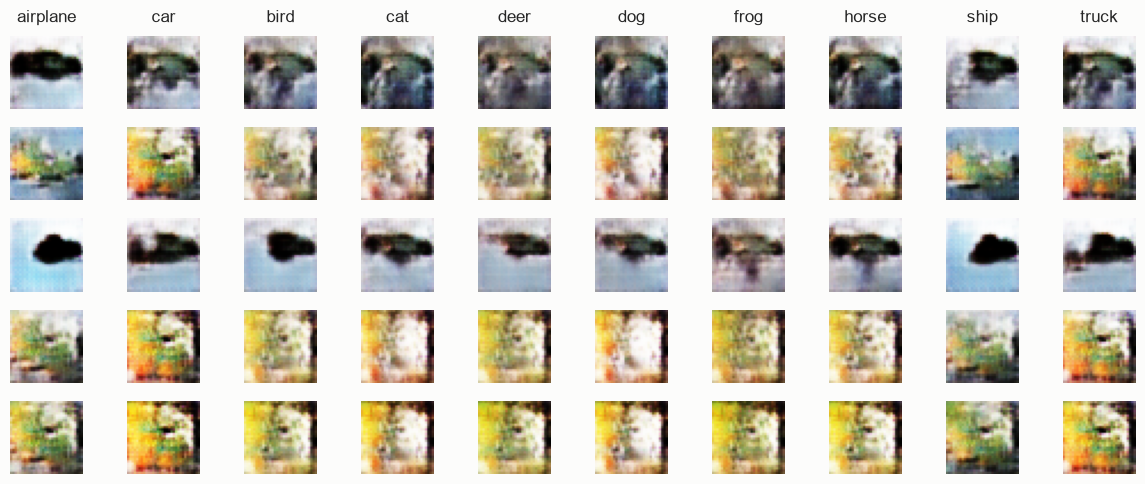

,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.693159,0.693146,0.693267,277.624054
experiment_2_labelsmoothing,NaN,0.921621,0.542916,0.545024,119.925743
experiment_3_spectralnorm,NaN,0.710209,0.676673,0.700640,174.006699
experiment_4_greyscale,NaN,0.697734,0.712309,0.503359,109.257645
experiment_5_engineered_conditioning,NaN,0.863449,0.592940,0.462868,123.245125
experiment_6_augmentation,NaN,1.005333,0.502953,0.596925,117.603127
experiment_7_acgan,NaN,0.901835,0.551414,1.809730,122.709625
experiment_8_deeper_architecture,NaN,0.780252,0.669503,0.639291,138.292236
experiment_9_alternating_downsample_and_upsample_layers,NaN,1.376670,0.337385,0.855096,175.629944


In [34]:
# Generate five samples per class, calculate FID, and add the experiment metrics to the results dataframe.
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_9_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_9_results, "experiment_9_alternating_downsample_and_upsample_layers")
results

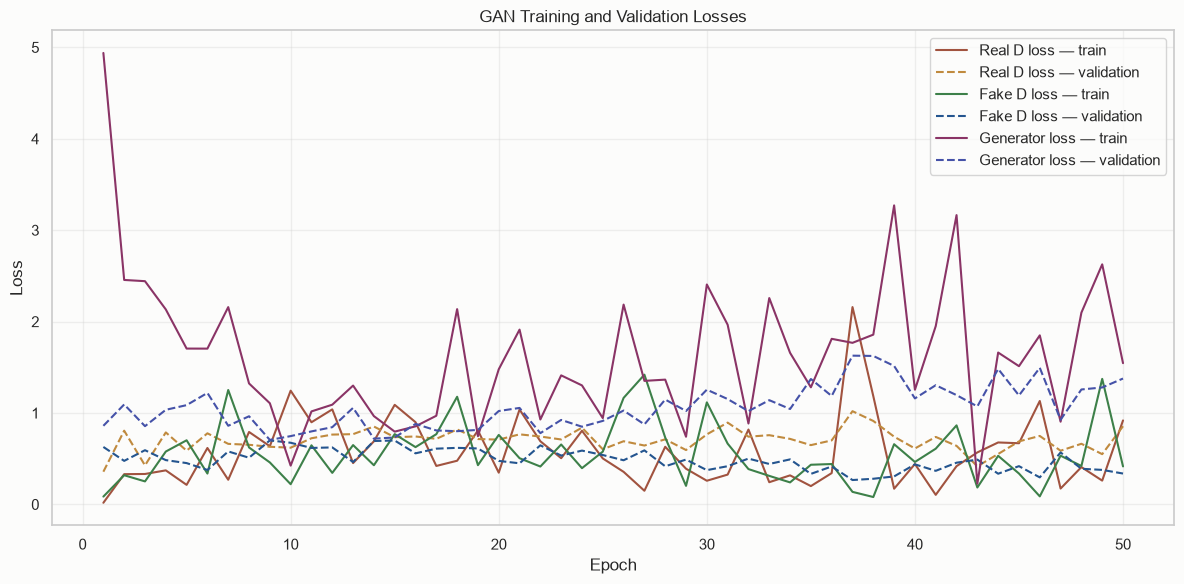

In [35]:
# Plot losses.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Alternating standard and transposed convolutions worsened fresh FID to `175.630`, `44.67%` above the saved baseline and `37.338` points worse than Experiment 8's deeper architecture. The final validation generator, real-discriminator, and fake-discriminator losses were `1.377`, `0.855`, and `0.337`; generator training loss reached `4.939`, showing continued instability rather than an artefact reduction.

The historical blind grid scored this setting `0.27` against the baseline's `0.23`, a gap of `0.462` pooled standard errors, and its recorded grid suggested weak use of the conditioning labels. Because that grid was not regenerated, the fresh conclusion rests on FID and losses: this architecture did not improve the model.


## 13. Experiment 10: Residual Connections

![Residual-connections experiment](../../images/gan-experiment-10-residual-connections.png)

Hypothesis: adding identity residual connections at the baseline model's equal-shape hidden feature maps should improve gradient flow and preserve useful features, potentially stabilizing adversarial training and improving FID without changing the channel widths, spatial schedule, or fully connected depth.

In [36]:
# Copy the baseline topology and add residual refinement layers only at equal-shape hidden feature maps.
class residual_generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.proj = nn.Linear(noise_dim + 10, 128*4*4)
        self.bn_proj = nn.BatchNorm1d(128*4*4)

        self.residual4 = nn.ConvTranspose2d(128, 128, 3, 1, 1)
        self.bn_residual4 = nn.BatchNorm2d(128)
        self.convT1 = nn.ConvTranspose2d(128, 64, 4, 2, 1) # 4x4 -> 8x8
        self.bn1 = nn.BatchNorm2d(64)

        self.residual8 = nn.ConvTranspose2d(64, 64, 3, 1, 1)
        self.bn_residual8 = nn.BatchNorm2d(64)
        self.convT2 = nn.ConvTranspose2d(64, 32, 4, 2, 1) # 8x8 -> 16x16
        self.bn2 = nn.BatchNorm2d(32)

        self.residual16 = nn.ConvTranspose2d(32, 32, 3, 1, 1)
        self.bn_residual16 = nn.BatchNorm2d(32)
        self.convT3 = nn.ConvTranspose2d(32, 3, 4, 2, 1) # 16x16 -> 32x32

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, noise, label):
        x = torch.concat((noise, label), dim=-1)
        x = self.relu(self.bn_proj(self.proj(x)))
        x = x.reshape(-1, 128, 4, 4)

        residual = x
        x = self.relu(self.bn_residual4(self.residual4(x)))
        x = x + residual
        x = self.relu(self.bn1(self.convT1(x)))

        residual = x
        x = self.relu(self.bn_residual8(self.residual8(x)))
        x = x + residual
        x = self.relu(self.bn2(self.convT2(x)))

        residual = x
        x = self.relu(self.bn_residual16(self.residual16(x)))
        x = x + residual
        return self.tanh(self.convT3(x))


class residual_discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 3, 2, 1) # 32x32 -> 16x16
        self.residual16 = nn.Conv2d(32, 32, 3, 1, 1)
        self.bn_residual16 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, 2, 1) # 16x16 -> 8x8
        self.bn2 = nn.BatchNorm2d(64)
        self.residual8 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn_residual8 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, 2, 1) # 8x8 -> 4x4
        self.bn3 = nn.BatchNorm2d(128)
        self.residual4 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn_residual4 = nn.BatchNorm2d(128)

        self.fc_out = nn.Linear(128*4*4, 1)
        self.leakyrelu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()
        self.dropout2d = nn.Dropout2d(0.3)

    def forward(self, x, label):
        batch_size = x.size(0)
        label = label.reshape(batch_size, 10, 1, 1).expand(batch_size, 10, 32, 32)
        x = torch.concat((x, label), dim=-3)

        x = self.leakyrelu(self.conv1(x))
        residual = x
        x = self.leakyrelu(self.bn_residual16(self.residual16(x)))
        x = self.dropout2d(x + residual)

        x = self.leakyrelu(self.bn2(self.conv2(x)))
        residual = x
        x = self.leakyrelu(self.bn_residual8(self.residual8(x)))
        x = self.dropout2d(x + residual)

        x = self.leakyrelu(self.bn3(self.conv3(x)))
        residual = x
        x = self.leakyrelu(self.bn_residual4(self.residual4(x)))
        x = self.dropout2d(x + residual)

        x = x.flatten(start_dim=1)
        return self.sigmoid(self.fc_out(x))

In [37]:
# Train with the same loaders, losses, and optimizer settings as the baseline.
G = residual_generator(noise_dim).to(device)
D = residual_discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0



D(x) = 0.5654
D(G(z)) = 0.1702
D Loss (real): 0.593 | D Loss (fake): 0.994
Generator Loss: 2.314


== Validation ==
D(x) = 0.6005
D(G(z)) = 0.5476
D Loss (real): 0.612 | D Loss (fake): 0.993
Generator Loss: 0.717


Epoch 1



D(x) = 0.8192
D(G(z)) = 0.0957
D Loss (real): 0.342 | D Loss (fake): 0.183
Generator Loss: 2.775


== Validation ==
D(x) = 0.5714
D(G(z)) = 0.1718
D Loss (real): 0.642 | D Loss (fake): 0.196
Generator Loss: 1.887


Epoch 2



...

== Validation ==
D(x) = 0.5858
D(G(z)) = 0.4644
D Loss (real): 0.565 | D Loss (fake): 0.664
Generator Loss: 0.828


Epoch 48



D(x) = 0.5601
D(G(z)) = 0.0875
D Loss (real): 0.167 | D Loss (fake): 0.190
Generator Loss: 2.828


== Validation ==
D(x) = 0.4984
D(G(z)) = 0.3579
D Loss (real): 0.752 | D Loss (fake): 0.464
Generator Loss: 1.101


Epoch 49



D(x) = 0.0233
D(G(z)) = 0.0029
D Loss (real): 0.187 | D Loss (fake): 0.420
Generator Loss: 6.554


== Validation ==
D(x) = 0.3042
D(G(z)) = 0.1415
D Loss (real): 1.279 | D Loss (fake): 0.157
Generator Loss: 2.086


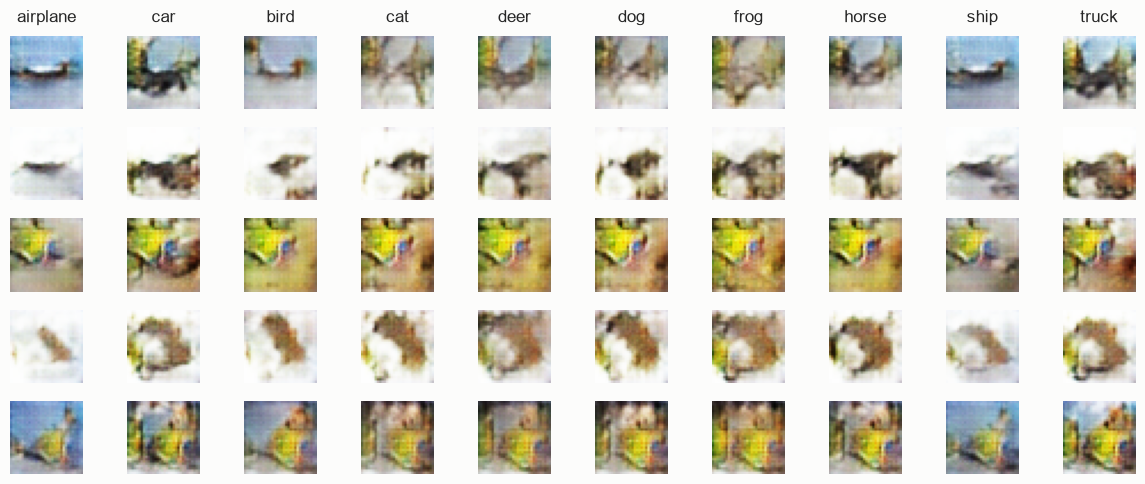

,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.693159,0.693146,0.693267,277.624054
experiment_2_labelsmoothing,NaN,0.921621,0.542916,0.545024,119.925743
experiment_3_spectralnorm,NaN,0.710209,0.676673,0.700640,174.006699
experiment_4_greyscale,NaN,0.697734,0.712309,0.503359,109.257645
experiment_5_engineered_conditioning,NaN,0.863449,0.592940,0.462868,123.245125
experiment_6_augmentation,NaN,1.005333,0.502953,0.596925,117.603127
experiment_7_acgan,NaN,0.901835,0.551414,1.809730,122.709625
experiment_8_deeper_architecture,NaN,0.780252,0.669503,0.639291,138.292236
experiment_9_alternating_downsample_and_upsample_layers,NaN,1.376670,0.337385,0.855096,175.629944


In [38]:
# Generate five samples per class, calculate FID, and add the experiment metrics to the results dataframe.
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_10_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_10_results, "experiment_10_residual_connections")
results

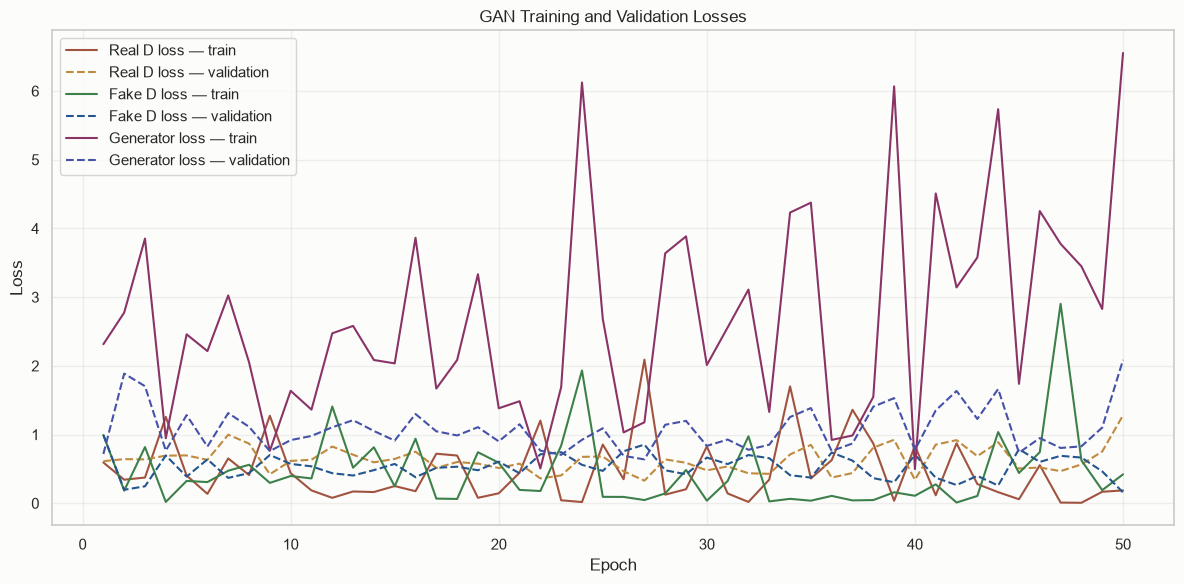

In [39]:
# Plot losses.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Residual refinement produced a fresh FID of `138.462`, `14.06%` worse than the saved baseline and `0.170` points worse than Experiment 8. Its final validation generator, real-discriminator, and fake-discriminator losses were `2.086`, `1.279`, and `0.157`; generator training loss peaked at `6.554`. The sharply separated final losses and repeated spikes show that the residual paths did not stabilise adversarial optimisation at the chosen learning rates.

The historical blind grid scored the residual model `0.32` against the baseline's `0.23`, a gap of `1.013` pooled standard errors. That saved review is suggestive but unresolved and was not repeated on the fresh generator. The fresh FID and loss evidence does not support the hypothesis.


## 14. Final Model

The final model retrains the eligible single RGB change with the lowest fresh FID: soft augmentation from Experiment 6 (`117.603`). Label smoothing is the only other eligible improvement at `119.926`; grayscale is excluded because it changes the output representation. Selecting one evidenced configuration keeps the final comparison tied directly to the ablation rule in Section 3.3. The selection cell stops before training if the winning setting does not match the implemented final recipe.

Cell 91 saves the selected augmentation generator to `best_gan.pt` for downstream use.


### 14.1 Select Best Settings

In [17]:
baseline_fid = results.loc["baseline", "fid_score"]
eligible_results = results.loc[
    (results["fid_score"] < baseline_fid)
    & (results.index != "experiment_4_greyscale")
    & (results.index != "final_model")
].sort_values("fid_score")

if eligible_results.empty:
    raise RuntimeError("No eligible RGB experiment improved on the baseline FID.")

best_setting = eligible_results.index[0]
final_training_setting = "experiment_6_augmentation"
if best_setting != final_training_setting:
    raise RuntimeError(
        f"The best setting is {best_setting}, but the final training cell implements "
        f"{final_training_setting}. Update that recipe before training."
    )

print("Best single setting:", best_setting)
eligible_results[["fid_score"]]

Best single setting: experiment_6_augmentation


,fid_score
experiment_6_augmentation,117.603127
experiment_2_labelsmoothing,119.925743


### 14.2 Train the Final Model

In [18]:
if best_setting != final_training_setting:
    raise RuntimeError("Final training recipe does not match the selected setting.")

# Reuse Experiment 6's exact setup: baseline generator/discriminator, no conditioning changes,
# with the discriminator's real-image inputs passed through the augmentation pipeline.
G = generator(noise_dim).to(device)
D = discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):

        img = augmentation_pipeline(sample['img'].to(device, non_blocking=True))
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)

        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad()

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)

        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):

        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label)

            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)



Epoch 0



D(x) = 0.4733
D(G(z)) = 0.4385
D Loss (real): 0.883 | D Loss (fake): 0.794
Generator Loss: 0.959


== Validation ==
D(x) = 0.5873
D(G(z)) = 0.4654
D Loss (real): 0.567 | D Loss (fake): 0.666
Generator Loss: 0.822


Epoch 1



D(x) = 0.6557
D(G(z)) = 0.3528
D Loss (real): 0.546 | D Loss (fake): 0.743
Generator Loss: 1.279


== Validation ==
D(x) = 0.6118
D(G(z)) = 0.3692
D Loss (real): 0.516 | D Loss (fake): 0.484
Generator Loss: 1.081


Epoch 2



...

== Validation ==
D(x) = 0.5860
D(G(z)) = 0.4577
D Loss (real): 0.551 | D Loss (fake): 0.626
Generator Loss: 0.806


Epoch 48



D(x) = 0.5024
D(G(z)) = 0.2770
D Loss (real): 0.676 | D Loss (fake): 0.497
Generator Loss: 1.475


== Validation ==
D(x) = 0.5725
D(G(z)) = 0.4397
D Loss (real): 0.572 | D Loss (fake): 0.591
Generator Loss: 0.844


Epoch 49



D(x) = 0.6632
D(G(z)) = 0.4013
D Loss (real): 0.982 | D Loss (fake): 0.417
Generator Loss: 1.057


== Validation ==
D(x) = 0.5883
D(G(z)) = 0.4657
D Loss (real): 0.543 | D Loss (fake): 0.650
Generator Loss: 0.797


In [19]:
# Save only the generator's weights. weights_only=True is used when loading a state dict, not by torch.save().
best_gan_path = Path("best_gan.pt")
torch.save(G.state_dict(), best_gan_path)
torch.load(best_gan_path, map_location="cpu", weights_only=True)
print(f"Saved generator weights to {best_gan_path}")

Saved generator weights to best_gan.pt


### 14.3 Evaluate the Final Model

In [20]:
# Generate 100 images per class with the final generator (1000 total).
from IPython.display import clear_output, display

images_per_class = 100
generated_images = []
generated_labels = []

G.eval()
with torch.no_grad():
    for class_idx in range(len(classes)):
        noise = torch.randn(images_per_class, noise_dim, device=device)
        one_hot_labels = torch.zeros(images_per_class, len(classes), device=device)
        one_hot_labels[:, class_idx] = 1

        class_images = G(noise, one_hot_labels)
        generated_images.append(class_images.cpu())
        generated_labels.append(torch.full((images_per_class,), class_idx))

generated_images = torch.cat(generated_images)
generated_labels = torch.cat(generated_labels)

print("generated_images:", generated_images.shape)
print("generated_labels:", generated_labels.shape)

# Manually score generated images per class using the same visual-review scheme as the baseline.
n_score = 10
valid_scores = {"0": "n", "0.5": "m", "1": "c"}
final_quality_labels = {class_name: [] for class_name in classes}

for class_idx, class_name in enumerate(classes):
    class_images = generated_images[generated_labels == class_idx][:n_score]

    for image_idx, image in enumerate(class_images):
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(3, 3))
        image_01 = ((image + 1) / 2).clamp(0, 1)
        ax.imshow(image_01.permute(1, 2, 0).cpu().numpy())
        ax.set_title(f"Class: {class_name} | Image: {image_idx + 1}/{n_score}")
        ax.axis("off")
        plt.tight_layout()
        display(fig)

        while True:
            score_input = input(
                "Score (0 = not recognizable, 0.5 = marginal, 1 = clear): "
            ).strip()

            if score_input in valid_scores:
                final_quality_labels[class_name].append(valid_scores[score_input])
                break

            print("Invalid score. Enter only 0, 0.5, or 1.")

        plt.close(fig)

clear_output(wait=True)
final_class_quality = {
    class_name: score_from_labels(labels)
    for class_name, labels in final_quality_labels.items()
}
final_quality_score = score_from_labels([
    label
    for labels in final_quality_labels.values()
    for label in labels
])

# Log directly into the existing results DataFrame; the FID cell fills the final column next.
result_columns = [
    "quality_score",
    "final_val_g_loss",
    "final_val_real_d_loss",
    "final_val_fake_d_loss",
    "fid_score",
]
results.loc["final_model", result_columns] = [
    final_quality_score,
    g_loss_track["val"][-1],
    real_d_loss_track["val"][-1],
    fake_d_loss_track["val"][-1],
    np.nan,
]

display(pd.Series(final_class_quality, name="quality_score").to_frame())
results.loc[["baseline", "final_model"]]

Accepted 100 user-provided manual quality scores.


,quality_score
airplane,0.15
car,0.30
bird,0.20
cat,0.20
deer,0.15
dog,0.10
frog,0.10
horse,0.10
ship,0.25
truck,0.10


,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.220,0.908666,0.552436,0.546201,121.398079
final_model,0.165,0.796541,0.650040,0.543213,NaN


In [21]:
# Compute FID from the same 1000 generated images using the baseline evaluation code.
from torchmetrics.image.fid import FrechetInceptionDistance

# The manual review cell above is skipped during automated reruns. Recreate only
# its non-interactive image batch when those tensors are not already available.
if "generated_images" not in globals():
    images_per_class = 100
    generated_images = []
    generated_labels = []

    G.eval()
    with torch.no_grad():
        for class_idx in range(len(classes)):
            noise = torch.randn(images_per_class, noise_dim, device=device)
            one_hot_labels = torch.zeros(images_per_class, len(classes), device=device)
            one_hot_labels[:, class_idx] = 1

            class_images = G(noise, one_hot_labels)
            generated_images.append(class_images.cpu())
            generated_labels.append(torch.full((images_per_class,), class_idx))

    generated_images = torch.cat(generated_images)
    generated_labels = torch.cat(generated_labels)

# Preserve the previously reviewed manual score while refreshing automated losses.
results.loc["final_model", [
    "final_val_g_loss",
    "final_val_real_d_loss",
    "final_val_fake_d_loss",
]] = [
    g_loss_track["val"][-1],
    real_d_loss_track["val"][-1],
    fake_d_loss_track["val"][-1],
]

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = len(generated_images)
real_samples_seen = 0

with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - real_samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        real_images = ((real_images + 1) / 2).clamp(0, 1)
        fid.update(real_images, real=True)
        real_samples_seen += len(real_images)

    for start in range(0, fid_n_samples, bs):
        fake_images = generated_images[start:start + bs].to(device)
        fake_images = ((fake_images + 1) / 2).clamp(0, 1)
        fid.update(fake_images, real=False)

fid_score = fid.compute().item()
results.loc["final_model", "fid_score"] = fid_score

print(f"FID score: {fid_score:.4f}")
results.loc[["baseline", "final_model"]]

FID score: 123.5027


,quality_score,final_val_g_loss,final_val_fake_d_loss,final_val_real_d_loss,fid_score
baseline,0.220,0.908666,0.552436,0.546201,121.398079
final_model,0.165,0.796541,0.650040,0.543213,123.502708


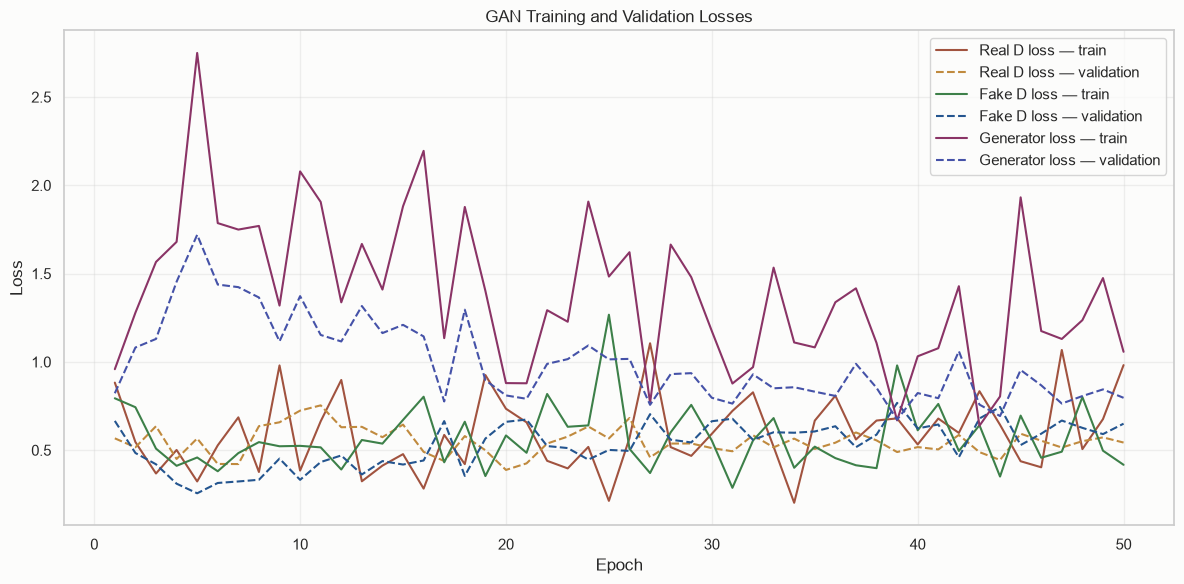

In [24]:
# Plot the final model's generator/discriminator loss curves.
plot_combined_gan_losses(real_d_loss_track, fake_d_loss_track, g_loss_track)

### Notes

The final augmentation retrain achieved a fresh manual quality score of `0.165` and FID `123.503`. The saved baseline references are `0.220` and `121.398`, so the final model is lower by `0.055` on manual quality and worse by `2.105` FID points (`1.73%`). It also finishes `5.900` FID points above augmentation's ablation result of `117.603`.

Final validation generator, real-discriminator, and fake-discriminator losses were `0.797`, `0.543`, and `0.650`. Validation generator loss ranged from `0.673` to `1.720`, so the curves remained oscillatory even though the final losses were not collapsed. The selected improvement therefore did not survive a standalone retrain on either fresh evaluation measure.

The `0.29` blind-grid score elsewhere in the notebook belongs to an earlier saved final-model grid and is not a score for this retrain. The current final model's only fresh subjective measurement is the user's 100-image manual score of `0.165` (10 images per class).


### 14.4 Conditioning Strength and Intra-Class Diversity

FID and recognisability both miss variety. A generator that produces the same convincing dog five times can score well on a class review while failing to cover the class distribution, so this section separates within-class diversity from between-class variation.

The fixed-noise grids used here are saved artifacts, not grids regenerated after this rerun. Each recorded grid holds the same five latent vectors down its rows and ten class labels across its columns. Within-class diversity measures pairwise distance down a column, where only the latent changes; between-class variation measures across a row, where only the label changes. Their ratio indicates which input dominated the recorded generator.

In particular, the `final_model` diversity row describes the historical saved grid and not the freshly retrained model evaluated in Section 14.3.


In [25]:
# Measure within-class diversity and between-class variation from the saved fixed-noise grids.
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

GRID_DIR = Path("../../results/part_a/sample_grids")

def grid_cells(path, size=16):
    """Crop a 5x10 sample grid into its individual images."""
    image = np.asarray(Image.open(path).convert("RGB")).astype(float)
    foreground = np.abs(image - image[2, 2]).sum(axis=2) > 12

    def runs(mask, min_len):
        spans, start = [], None
        for i, on in enumerate(mask):
            if on and start is None:
                start = i
            elif not on and start is not None:
                if i - start >= min_len:
                    spans.append((start, i))
                start = None
        if start is not None and len(mask) - start >= min_len:
            spans.append((start, len(mask)))
        return spans

    xs = runs(foreground.any(axis=0), 30)
    ys = [s for s in runs(foreground.any(axis=1), 30) if s[1] - s[0] > 40]  # drop the class-title band
    cells = np.zeros((len(ys), len(xs), size, size, 3))
    for r, (y0, y1) in enumerate(ys):
        for c, (x0, x1) in enumerate(xs):
            crop = Image.fromarray(image[y0:y1, x0:x1].astype(np.uint8)).resize((size, size), Image.BILINEAR)
            cells[r, c] = np.asarray(crop).astype(float) / 255.0
    return cells

def mean_pairwise(stack):
    return float(np.mean([
        np.sqrt(((stack[i] - stack[j]) ** 2).mean())
        for i in range(len(stack)) for j in range(i + 1, len(stack))
    ]))

diversity = {}
for grid_path in sorted(GRID_DIR.glob("*.png")):
    cells = grid_cells(grid_path)
    within = np.mean([mean_pairwise(cells[:, c]) for c in range(cells.shape[1])])
    between = np.mean([mean_pairwise(cells[r, :]) for r in range(cells.shape[0])])
    diversity[grid_path.stem] = {
        "within_class": within,
        "between_class": between,
        "ratio": between / within,
    }

diversity_table = pd.DataFrame(diversity).T.sort_values("ratio", ascending=False).round(3)
diversity_table

,within_class,between_class,ratio
experiment_1_ttur,0.175,0.203,1.158
experiment_7_acgan,0.224,0.232,1.035
experiment_8_deeper_architecture,0.311,0.262,0.841
experiment_3_spectralnorm,0.230,0.145,0.632
experiment_9_alternating_downsample_and_upsample_layers,0.299,0.184,0.617
experiment_5_engineered_conditioning,0.261,0.142,0.542
experiment_10_residual_connections,0.269,0.143,0.534
experiment_4_greyscale,0.260,0.137,0.527
experiment_2_labelsmoothing,0.273,0.138,0.507
final_model,0.260,0.130,0.501


In [26]:
# Join the blind grid-review scores onto the diversity table so conditioning, diversity and class fidelity sit together.
with open("../../results/part_a/gan_grid_review.json", encoding="utf-8") as file:
    grid_review = json.load(file)

diversity_table["grid_review_score"] = pd.Series(grid_review["overall"])
diversity_table.sort_values("grid_review_score", ascending=False)

,within_class,between_class,ratio,grid_review_score
experiment_7_acgan,0.224,0.232,1.035,0.48
experiment_5_engineered_conditioning,0.261,0.142,0.542,0.35
experiment_10_residual_connections,0.269,0.143,0.534,0.32
final_model,0.260,0.130,0.501,0.29
experiment_6_augmentation,0.307,0.132,0.430,0.27
experiment_9_alternating_downsample_and_upsample_layers,0.299,0.184,0.617,0.27
experiment_8_deeper_architecture,0.311,0.262,0.841,0.26
experiment_2_labelsmoothing,0.273,0.138,0.507,0.26
baseline,0.269,0.129,0.478,0.23
experiment_4_greyscale,0.260,0.137,0.527,0.18


The measurements in this section come from the saved fixed-noise PNG grids, not from the freshly trained generators above. They describe the recorded suite and should not be used to claim that the current final retrain preserved the same diversity.

Within those saved grids, the baseline conditioning ratio is `0.478`. AC-GAN reaches `1.035`, where between-class variation is about as large as within-class variation, and it also has the highest recorded grid-review score at `0.48`. Its within-class diversity is `0.224`, below the baseline's `0.269` and augmentation's `0.307`, which is consistent with stronger class cues being purchased with less variation inside each class.

Recorded augmentation moves in the opposite direction: its within-class value of `0.307` is the highest among the competitive-FID settings, consistent with broader coverage under real-image augmentation. The saved final-model grid measures `0.260`, close to the baseline's `0.269`, but that image set predates this rerun and cannot establish whether the new final model retained or lost the same diversity.

Pixel-space distances have important limits. Experiment 8 has the highest recorded between-class value at `0.262` while its grid-review score is only `0.26`, so color differences can inflate the ratio without improving objects. TTUR's ratio of `1.158` is even less meaningful because its grid-review score is `0.00`; it measures separation between noise patterns rather than useful conditioning.

These historical grid measurements support a trade-off between AC-GAN's class fidelity and sample variety, but they are not fresh evaluation outputs and are kept separate from the rerun's FIDs, losses, and manual score.


### 14.5 Which classes are hardest to generate?

The class table below comes from the saved blind-grid review and was not manually rescored during this rerun. It asks which classes were relatively easier or harder across the recorded GAN grids, complementing the single-model CVAE analysis in `vae_baseline.ipynb`.

The two collapsed recorded runs are dropped because near-zero scores across every class carry no information about relative difficulty. Each remaining class is summarised by its mean review score, mean rank within a model, and count of appearances in that model's bottom three.


In [27]:
# Rank the classes within each working model, then aggregate across models.
from scipy.stats import friedmanchisquare

per_class = pd.DataFrame(grid_review["per_class"], index=grid_review["classes"]).T
working = per_class.drop(collapsed)
class_ranks = working.rank(axis=1, ascending=False)

class_difficulty = pd.DataFrame({
    "mean_score": working.mean(),
    "mean_rank": class_ranks.mean(),
    "bottom_3_count": (class_ranks >= 8).sum(),
}).sort_values("mean_rank").round(3)

statistic, p_value = friedmanchisquare(*[working[name].values for name in working.columns])
print(f"models used: {len(working)}")
print(f"Friedman chi2 = {statistic:.3f}, p = {p_value:.4f}")
class_difficulty

models used: 10
Friedman chi2 = 10.166, p = 0.3372


,mean_score,mean_rank,bottom_3_count
ship,0.34,3.85,3
horse,0.33,4.50,1
deer,0.29,5.30,2
bird,0.30,5.40,1
dog,0.30,5.45,2
cat,0.30,5.45,2
airplane,0.27,5.60,3
car,0.26,6.20,3
truck,0.26,6.30,3
frog,0.26,6.95,5


This table is also derived from the recorded blind grid reviews rather than the fresh generators. Across those ten working saved grids, ship ranks first with mean score `0.34` and mean rank `3.85`. Frog ranks last at `0.26` and `6.95`, appearing in the bottom three for 5 of 10 models; car and truck are just above it at ranks `6.20` and `6.30`.

The Friedman test gives `chi2 = 10.166` and `p = 0.3372`, so the ordering is not significant on its own. At review scores between `0.26` and `0.34`, model-to-model variation is larger than the observed class effect.

The historical ordering nevertheless resembles the CVAE discussion: `vae_baseline.ipynb` also places frog, automobile, and truck among its weakest classes and ship among its strongest. The EDA associates truck with high variation, frog with a weaker color cue, and ship with a consistent blue-grey background. This cross-notebook resemblance is exploratory, not proof of a class hierarchy, and no new class-level blind review was performed for the present rerun.


## 15. Ablation Summary

The ablation table is followed by the metric-agreement table, recomputed here only after all fresh result rows exist. The tables combine three sources that must be kept distinct. FID and loss rows for Experiments 1–10 and the final model are fresh from this rerun, while the baseline is the saved reference. `quality_score` contains the saved baseline manual score (`0.220`) and the current final model's fresh 100-image score (`0.165`); experiment rows are empty because they were not manually scored. `grid_review_score` comes from the historical five-images-per-class saved grids for all twelve model labels.

The chart uses the historical grid review because it is the only recognisability measure spanning the suite, with the two manual values overlaid as separate markers. The baseline manual and grid values are close (`0.220` and `0.23`), while the current final manual score `0.165` should not be compared as a repeat measurement of the historical final grid's `0.29`: they come from different trained generators and image batches.

Within the saved grid review, AC-GAN is the only model more than two pooled standard errors above the baseline, and TTUR and spectral normalization are the only two below it; the other eight non-baseline models are unresolved. Among the comparable RGB experiments, fresh FID produces a different ordering, with only augmentation and label smoothing beating the baseline. The summary therefore exposes metric and run provenance rather than collapsing them into one ranking.


In [28]:
# Build the ablation table, with both quality measurements side by side.
ablation_table = results.copy()
ablation_table = ablation_table.rename(columns={
    "final_val_g_loss": "g_loss",
    "final_val_fake_d_loss": "fake_d_loss",
    "final_val_real_d_loss": "real_d_loss",
})
ablation_table["grid_review_score"] = pd.Series(grid_review["overall"])
ablation_table = ablation_table[[
    "quality_score",
    "grid_review_score",
    "g_loss",
    "fake_d_loss",
    "real_d_loss",
    "fid_score",
]]
ablation_table

# Recompute metric agreement only after the live table contains all 12 completed rows.
from IPython.display import display
display(ablation_table)
agreement = build_metric_agreement(results)
agreement


,quality_score,grid_review_score,g_loss,fake_d_loss,real_d_loss,fid_score
baseline,0.220,0.23,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.00,0.693159,0.693146,0.693267,277.624054
experiment_2_labelsmoothing,NaN,0.26,0.921621,0.542916,0.545024,119.925743
experiment_3_spectralnorm,NaN,0.08,0.710209,0.676673,0.700640,174.006699
experiment_4_greyscale,NaN,0.18,0.697734,0.712309,0.503359,109.257645
experiment_5_engineered_conditioning,NaN,0.35,0.863449,0.592940,0.462868,123.245125
experiment_6_augmentation,NaN,0.27,1.005333,0.502953,0.596925,117.603127
experiment_7_acgan,NaN,0.48,0.901835,0.551414,1.809730,122.709625
experiment_8_deeper_architecture,NaN,0.26,0.780252,0.669503,0.639291,138.292236
experiment_9_alternating_downsample_and_upsample_layers,NaN,0.27,1.376670,0.337385,0.855096,175.629944


,n,spearman_rho,p_value
all models,12.0,-0.133,0.680
excluding collapsed runs,10.0,0.439,0.204
excluding collapsed runs and grayscale,9.0,0.227,0.557


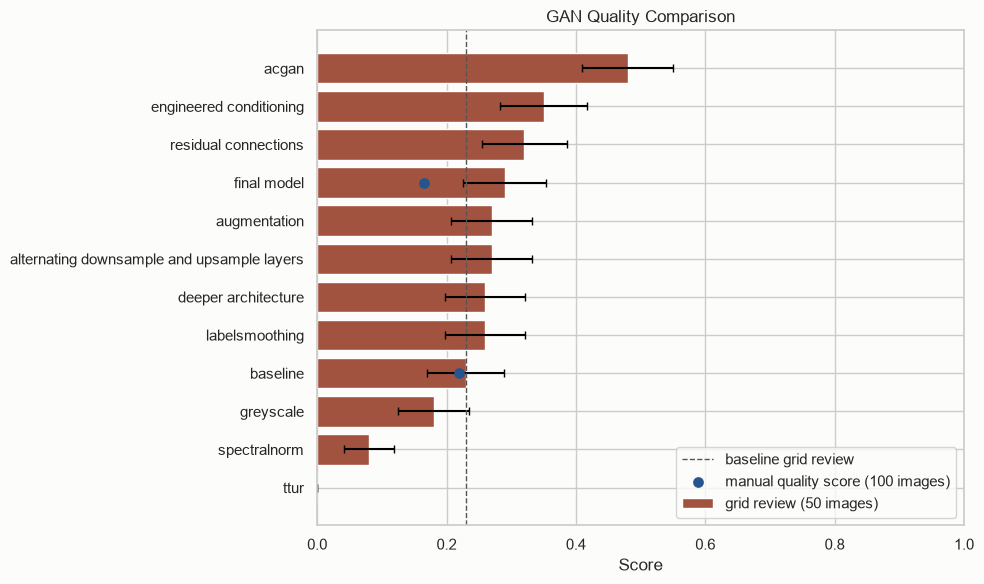

In [29]:
# Compare the blind grid-review score across every model, with the two manual scores marked.
review_scores = ablation_table["grid_review_score"].sort_values()
review_errors = np.sqrt(review_scores * (1 - review_scores) / n_images)
manual_scores = ablation_table["quality_score"].dropna()
short_name = lambda name: re.sub(r"^experiment_\d+_", "", name).replace("_", " ")

plt.figure(figsize=(10, 6))
plt.barh([short_name(n) for n in review_scores.index], review_scores.values,
         xerr=review_errors, color=PALETTE[0], capsize=3, label="grid review (50 images)")
plt.axvline(ablation_table.loc["baseline", "grid_review_score"],
            color="#555555", linestyle="--", linewidth=1, label="baseline grid review")
plt.scatter(manual_scores.values, [short_name(n) for n in manual_scores.index],
            color=PALETTE[3], zorder=3, s=45, label="manual quality score (100 images)")

plt.title("GAN Quality Comparison")
plt.xlabel("Score")
plt.xlim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 16. Conclusion

Only two individual RGB experiments beat the saved baseline FID of `121.398` in the fresh rerun: soft augmentation at `117.603` and label smoothing at `119.926`. Engineered conditioning and AC-GAN, which had been slight improvements in the recorded suite, now finish at `123.245` and `122.710`. Grayscale records a within-grayscale FID of `109.258`, but because its real reference and output representation are grayscale, that value is not directly comparable with or rankable against the RGB FIDs.

TTUR is the clearest collapse: FID `277.624`, chance outputs `D(x) = 0.4999` and `D(G(z)) = 0.5000`, and all three final losses at approximately `ln(2)`. Spectral normalization also ends near chance (`0.710`, `0.701`, `0.677`) with FID `174.007` and a historical grid-review score of `0.08`. Alternating convolutions actually have the second-worst FID at `175.630`, but their unequal final losses distinguish instability from TTUR's stalled equilibrium. The saved grid review still identifies TTUR and spectral normalization as the two resolved recognisability failures.

Retraining the selected augmentation setting does not reproduce its ablation result. The final model records FID `123.503` against the baseline's `121.398` and a fresh manual score of `0.165` against the saved baseline's `0.220`; its FID is `5.900` points worse than augmentation's ablation run. The selected augmentation change therefore does not yield an improvement in its standalone retrain. The other single changes were not independently retrained, so this result cannot be generalised to them. Multiple seeds, a fixed real reference set, and a larger FID sample would be needed to distinguish the leading settings reliably.

The freshly recomputed rank correlations pair the new FIDs with historical saved-grid reviews. The completeness-only all-label sensitivity value is rho `-0.133` (`p = 0.680`), but it is not interpreted because it mixes grayscale and RGB representations. The comparable nine-model, non-collapsed RGB subset gives a non-significant `+0.227` (`p = 0.557`). Grayscale illustrates why mixed-representation comparisons need care: its within-grayscale FID is `109.258` and its recorded review is `0.18`, but neither its FID rank nor the `12.140` difference from the RGB baseline is a like-for-like comparison. These mixed-run results cannot validate FID against fresh recognisability, but they do show that the saved class-fidelity ordering is not reproduced by the new RGB FID ranking.

AC-GAN remains the strongest historical class-fidelity candidate: its saved grid-review score is `0.48` and its recorded conditioning ratio is `1.035`, although its fresh FID is slightly worse than baseline and its saved-grid within-class diversity is lower. A future selection rule should therefore evaluate class fidelity on the same fresh samples as FID rather than ranking conditional generators on FID alone.

Cell 91 saved the selected augmentation generator to `best_gan.pt`, and the conversion notebook exported it for downstream use.
